In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import torch, glob, re, os, math
from sklearn.cluster import KMeans
from scipy.signal import find_peaks
from scipy import sparse
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import mannwhitneyu, gaussian_kde
import plotly.graph_objects as go
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import numpy as np
import scvi
import scipy.sparse as sp
import torch.nn.functional as F

In [2]:
data_dir      = "data/GP1/processed"
save_dir      = "outputs/GP1/casestudy/ds_ana/counts_MLP"

In [3]:
adata_ori = sc.read_h5ad(f'{data_dir}/GP1.h5ad')
adata_ori.obs_names_make_unique()
adata_ori

AnnData object with n_obs × n_vars = 391 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side', 'status', 'source', 'cx_aligned', 'cy_aligned'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [4]:
files = sorted(glob.glob(os.path.join(save_dir, "*.h5ad")))
adatas = {}
for path in files:
    filename = os.path.basename(path)
    sample_id = os.path.splitext(filename)[0]  
    sample_adata = sc.read_h5ad(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

In [ ]:
def format_frame_to_name(x):
    x = int(x)
    t_str = f"{x/100:.4f}".replace(".", "p")
    return f"normal_to_cancer_f{x:04d}_t{t_str}"

adata.obs["frame"] = adata.obs["frame"].apply(format_frame_to_name)
print(adata.obs["sample"].value_counts())
print(adata.obs["frame"].value_counts())
print(adata.obs["t"].value_counts())

sample
counts_pred_sample100    246
counts_pred_sample99     245
counts_pred_sample98     244
counts_pred_sample97     243
counts_pred_sample96     242
                        ... 
counts_pred_sample04     149
counts_pred_sample03     148
counts_pred_sample02     147
counts_pred_sample01     146
counts_pred_sample00     145
Name: count, Length: 101, dtype: int64
frame
normal_to_cancer_f0100_t1p0000    246
normal_to_cancer_f0099_t0p9900    245
normal_to_cancer_f0098_t0p9800    244
normal_to_cancer_f0097_t0p9700    243
normal_to_cancer_f0096_t0p9600    242
                                 ... 
normal_to_cancer_f0004_t0p0400    149
normal_to_cancer_f0003_t0p0300    148
normal_to_cancer_f0002_t0p0200    147
normal_to_cancer_f0001_t0p0100    146
normal_to_cancer_f0000_t0p0000    145
Name: count, Length: 101, dtype: int64
t
100    246
99     245
98     244
97     243
96     242
      ... 
4      149
3      148
2      147
1      146
0      145
Name: count, Length: 101, dtype: int64


In [6]:
# def _build_boxes_polydata_from_slices(points_by_slice, slice_values=None):
#     """
#     points_by_slice: list of (n_i, 3) arrays
#     slice_values:    list of slice id / t
#     """
#     vtk_points = vtk.vtkPoints()
#     lines = vtk.vtkCellArray()

#     box_slice_ids = vtk.vtkIntArray()
#     box_slice_ids.SetName("slice_id")

#     if slice_values is None:
#         slice_values = list(range(len(points_by_slice)))

#     pid_offset = 0
#     n_boxes = 0

#     for pts, sid in zip(points_by_slice, slice_values):
#         if pts is None or len(pts) == 0:
#             continue

#         pts = np.asarray(pts, dtype=np.float32)
#         xmin, ymin, zmin = pts.min(axis=0)
#         xmax, ymax, zmax = pts.max(axis=0)
#         z = 0.5 * (zmin + zmax)

#         corners = [
#             (xmin, ymin, z),  # p0
#             (xmax, ymin, z),  # p1
#             (xmax, ymax, z),  # p2
#             (xmin, ymax, z),  # p3
#         ]

#         for p in corners:
#             vtk_points.InsertNextPoint(float(p[0]), float(p[1]), float(p[2]))

#         edges = [
#             (pid_offset + 0, pid_offset + 1),
#             (pid_offset + 1, pid_offset + 2),
#             (pid_offset + 2, pid_offset + 3),
#             (pid_offset + 3, pid_offset + 0),
#         ]

#         for a, b in edges:
#             line = vtk.vtkLine()
#             line.GetPointIds().SetId(0, a)
#             line.GetPointIds().SetId(1, b)
#             lines.InsertNextCell(line)
#             box_slice_ids.InsertNextValue(int(sid))

#         pid_offset += 4
#         n_boxes += 1

#     boxes_poly = vtk.vtkPolyData()
#     boxes_poly.SetPoints(vtk_points)
#     boxes_poly.SetLines(lines)
#     boxes_poly.GetCellData().AddArray(box_slice_ids)

#     return boxes_poly, n_boxes


# def _extract_t_from_frame_series(frame_series):
#     frame_str = frame_series.astype(str)
#     t = frame_str.str.extract(r"_f(\d+)_", expand=False)
#     if t.isna().any():
#         bad = frame_str[t.isna()].unique()[:10]
#         raise ValueError(f" frame  f ,: {bad}")
#     return t.astype(int)


# def _infer_layer_col(obs, layer_col=None):
#     if layer_col is not None:
#         if layer_col not in obs.columns:
#             raise KeyError(f"obs missing {layer_col}")
#         return layer_col

#     if "layer_idx" in obs.columns:
#         return "layer_idx"
#     elif "layer_name" in obs.columns:
#         return "layer_name"
#     else:
#         raise KeyError(" layer_idx  layer_name")


# def _get_xy_from_adata(adata, obs, use_spatial_if_available=True, x_col="cx", y_col="cy"):
#     if use_spatial_if_available and "spatial" in adata.obsm:
#         xy = np.asarray(adata.obsm["spatial"], dtype=np.float32)
#         if xy.shape[0] != obs.shape[0]:
#             raise ValueError("adata.obsm['spatial']  adata.obs mismatch")
#         X_all = xy[:, 0]
#         Y_all = xy[:, 1]
#     else:
#         if x_col not in obs.columns or y_col not in obs.columns:
#             raise KeyError(f"missing spatial,missing {x_col}/{y_col}")
#         X_all = pd.to_numeric(obs[x_col], errors="coerce").to_numpy(np.float32)
#         Y_all = pd.to_numeric(obs[y_col], errors="coerce").to_numpy(np.float32)
#     return X_all, Y_all


# def _get_z_from_obs(obs, frame_col="frame", z_from="frame", z_scale=1.0):
#     if z_from == "frame":
#         if frame_col not in obs.columns:
#             raise KeyError(f"obs missing {frame_col}")
#         t_ser = _extract_t_from_frame_series(obs[frame_col])
#         t_int_all = t_ser.to_numpy(np.int32)
#         Z_all = t_ser.to_numpy(np.float32) * float(z_scale)
#         return t_int_all, Z_all
#     else:
#         raise ValueError(" z_from  'frame'")


# def _get_uid_from_obs(obs, uid_col="uid"):
#     if uid_col in obs.columns:
#         return obs[uid_col].astype(str).to_numpy()
#     return pd.Index(obs.index).astype(str).to_numpy()


# def _make_layer_mask(layer_series, layer_keep=(1, 2)):
#     if pd.api.types.is_numeric_dtype(layer_series):
#         return pd.to_numeric(layer_series, errors="coerce").isin(list(layer_keep)).to_numpy()
#     else:
#         return layer_series.astype(str).isin([str(x) for x in layer_keep]).to_numpy()


# def _make_end_mask(t_int_all, n_end_slices=1):
#     uniq_t = np.sort(np.unique(t_int_all))
#     if len(uniq_t) == 0:
#         raise ValueError("missing slice / t")

#     n_end_slices = max(int(n_end_slices), 1)
#     first_ts = uniq_t[:n_end_slices]
#     last_ts = uniq_t[-n_end_slices:]
#     end_ts = np.unique(np.concatenate([first_ts, last_ts]))

#     end_mask = np.isin(t_int_all, end_ts)
#     return end_mask, end_ts


# def _build_polydata_from_mask(
#     obs,
#     X_all,
#     Y_all,
#     Z_all,
#     uid_all,
#     t_int_all,
#     keep_mask,
#     extra_obs_cols=("layer_name", "layer_idx", "is_birth", "is_diff", "diff_alpha_post"),
# ):
#     obs_sub = obs.loc[keep_mask].copy()
#     X = X_all[keep_mask]
#     Y = Y_all[keep_mask]
#     Z = Z_all[keep_mask]
#     uid = uid_all[keep_mask]
#     t_int = t_int_all[keep_mask]

#     valid = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
#     obs_valid = obs_sub.loc[valid].copy()
#     X = X[valid]
#     Y = Y[valid]
#     Z = Z[valid]
#     uid = uid[valid]
#     t_int = t_int[valid]

#     pts_np = np.c_[X, Y, Z].astype(np.float32)

#     vtk_points = vtk.vtkPoints()
#     if len(pts_np) > 0:
#         vtk_points.SetData(numpy_to_vtk(pts_np, deep=True))

#     poly = vtk.vtkPolyData()
#     poly.SetPoints(vtk_points)

#     verts = vtk.vtkCellArray()
#     for i in range(len(pts_np)):
#         verts.InsertNextCell(1)
#         verts.InsertCellPoint(i)
#     poly.SetVerts(verts)

#     uid_arr = vtk.vtkStringArray()
#     uid_arr.SetName("uid")
#     for s in uid:
#         uid_arr.InsertNextValue(str(s))
#     poly.GetPointData().AddArray(uid_arr)

#     t_arr = numpy_to_vtk(t_int.astype(np.int32), deep=True)
#     t_arr.SetName("t")
#     poly.GetPointData().AddArray(t_arr)

#     for col in extra_obs_cols:
#         if col not in obs_valid.columns:
#             continue

#         v = obs_valid[col]

#         if pd.api.types.is_bool_dtype(v):
#             arr = numpy_to_vtk(v.astype(np.int8).to_numpy(), deep=True)
#             arr.SetName(col)
#             poly.GetPointData().AddArray(arr)

#         elif pd.api.types.is_numeric_dtype(v):
#             arr = numpy_to_vtk(
#                 pd.to_numeric(v, errors="coerce").fillna(0).to_numpy(np.float32),
#                 deep=True
#             )
#             arr.SetName(col)
#             poly.GetPointData().AddArray(arr)

#         else:
#             sarr = vtk.vtkStringArray()
#             sarr.SetName(col)
#             v_str = v.astype("string").fillna("")
#             for x in v_str:
#                 sarr.InsertNextValue(str(x))
#             poly.GetPointData().AddArray(sarr)

#     return poly, pts_np, obs_valid, t_int


# def _write_polydata(poly, out_vtp):
#     os.makedirs(os.path.dirname(os.path.abspath(out_vtp)), exist_ok=True)
#     writer = vtk.vtkXMLPolyDataWriter()
#     writer.SetFileName(str(out_vtp))
#     writer.SetInputData(poly)
#     writer.Write()


# def export_adata_points_split_vtp(
#     adata,
#     out_middle_vtp,
#     out_end_vtp,
#     out_boxes_vtp,
#     frame_col="frame",
#     uid_col="uid",
#     use_spatial_if_available=True,
#     x_col="cx",
#     y_col="cy",
#     z_from="frame",
#     z_scale=1.0,
#     layer_col=None,
#     layer_keep=(1, 2),
#     extra_obs_cols=("layer_name", "layer_idx", "is_birth", "is_diff", "diff_alpha_post"),
#     n_end_slices=1,   # ;1+1
# ):
#     """
#     output:
#     1) out_middle_vtp: , layer_keep
#     2) out_end_vtp   : ,
#     3) out_boxes_vtp : ( +  layer_keep) box
#     """
#     obs = adata.obs.copy()

#     layer_col = _infer_layer_col(obs, layer_col=layer_col)
#     X_all, Y_all = _get_xy_from_adata(
#         adata, obs,
#         use_spatial_if_available=use_spatial_if_available,
#         x_col=x_col, y_col=y_col
#     )
#     t_int_all, Z_all = _get_z_from_obs(
#         obs,
#         frame_col=frame_col,
#         z_from=z_from,
#         z_scale=z_scale
#     )
#     uid_all = _get_uid_from_obs(obs, uid_col=uid_col)

#     layer_mask = _make_layer_mask(obs[layer_col], layer_keep=layer_keep)
#     end_mask, end_ts = _make_end_mask(t_int_all, n_end_slices=n_end_slices)

#     middle_mask = (~end_mask) & layer_mask
#     end_full_mask = end_mask
#     all_kept_mask = end_full_mask | middle_mask

#     if all_kept_mask.sum() == 0:
#         raise ValueError("missing, layer_keep / n_end_slices / coordinatescolumn")

#     # ---------- middle:  1/2 ----------
#     poly_middle, pts_middle, obs_middle, t_middle = _build_polydata_from_mask(
#         obs=obs,
#         X_all=X_all,
#         Y_all=Y_all,
#         Z_all=Z_all,
#         uid_all=uid_all,
#         t_int_all=t_int_all,
#         keep_mask=middle_mask,
#         extra_obs_cols=extra_obs_cols,
#     )
#     _write_polydata(poly_middle, out_middle_vtp)

#     # ---------- end:  ----------
#     poly_end, pts_end, obs_end, t_end = _build_polydata_from_mask(
#         obs=obs,
#         X_all=X_all,
#         Y_all=Y_all,
#         Z_all=Z_all,
#         uid_all=uid_all,
#         t_int_all=t_int_all,
#         keep_mask=end_full_mask,
#         extra_obs_cols=extra_obs_cols,
#     )
#     _write_polydata(poly_end, out_end_vtp)

#     # ---------- boxes:  ----------
#     _, pts_all_kept, obs_all_kept, t_all_kept = _build_polydata_from_mask(
#         obs=obs,
#         X_all=X_all,
#         Y_all=Y_all,
#         Z_all=Z_all,
#         uid_all=uid_all,
#         t_int_all=t_int_all,
#         keep_mask=all_kept_mask,
#         extra_obs_cols=extra_obs_cols,
#     )

#     points_by_slice = []
#     slice_values = []
#     for tt in np.sort(np.unique(t_all_kept)):
#         m = (t_all_kept == tt)
#         pts_slice = pts_all_kept[m]
#         if pts_slice.shape[0] == 0:
#             continue
#         points_by_slice.append(pts_slice)
#         slice_values.append(int(tt))

#     boxes_poly, n_boxes = _build_boxes_polydata_from_slices(
#         points_by_slice,
#         slice_values=slice_values
#     )
#     _write_polydata(boxes_poly, out_boxes_vtp)

#     print("=" * 60)
#     print(f"Middle VTP : {out_middle_vtp}")
#     print(f"  , layers = {layer_keep}")
#     print(f"  : {poly_middle.GetNumberOfPoints()}")

#     print(f"End VTP    : {out_end_vtp}")
#     print(f"   {n_end_slices} ,")
#     print(f"   t: {list(end_ts)}")
#     print(f"  : {poly_end.GetNumberOfPoints()}")

#     print(f"Boxes VTP  : {out_boxes_vtp}")
#     print(f"  box : {n_boxes}")
#     print("  box : + ")
#     print("=" * 60)

#     return {
#         "middle_poly": poly_middle,
#         "end_poly": poly_end,
#         "boxes_poly": boxes_poly,
#         "middle_n_points": poly_middle.GetNumberOfPoints(),
#         "end_n_points": poly_end.GetNumberOfPoints(),
#         "n_boxes": n_boxes,
#         "end_ts": end_ts,
#     }

In [7]:
# res = export_adata_points_split_vtp(
#     adata=adata,
#     out_middle_vtp="middle_layer.vtp",
#     out_end_vtp="end_full.vtp",
#     out_boxes_vtp="slice_boxes.vtp",
#     frame_col="frame",
#     uid_col="uid",
#     use_spatial_if_available=False,   
#     x_col="x_roll",
#     y_col="y_roll",
#     z_from="frame",
#     z_scale=1.0,
#     layer_col="layer_name",            
#     layer_keep=(1,6,7,8,9,12),
#     n_end_slices=1,                   
# )

In [8]:
adata_full = sc.read("data/GP1/processed/GP1_with_metadata.h5ad")
adata_full

AnnData object with n_obs × n_vars = 2174 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'

In [9]:
def split_cluster_state_upper_lower(
    adata,
    cluster_col="cluster",
    normal_clusters=("7", "8", "12"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"adata.obs missing {cluster_col}")

    if "spatial" not in adata.obsm:
        raise KeyError("adata.obsm missing 'spatial'")

    ad = adata.copy()

    # 1) cluster , 16 -> 1
    ad.obs[cluster_col] = ad.obs[cluster_col].astype(str)
    if merge_map is not None:
        ad.obs[cluster_col] = ad.obs[cluster_col].replace(merge_map)

    # 2)  cluster
    keep_clusters = set(map(str, normal_clusters)) | set(map(str, cancer_clusters))
    ad = ad[ad.obs[cluster_col].isin(keep_clusters)].copy()

    # 3)  normal / cancer
    normal_clusters = set(map(str, normal_clusters))
    cancer_clusters = set(map(str, cancer_clusters))

    ad.obs["state"] = np.where(
        ad.obs[cluster_col].isin(normal_clusters),
        "normal",
        "cancer"
    )
    ad.obs["state"] = pd.Categorical(ad.obs["state"], categories=["normal", "cancer"])

    # 4)  spatial  y  upper / lower
    xy = np.asarray(ad.obsm["spatial"])
    y = xy[:, 1].reshape(-1, 1)

    km = KMeans(n_clusters=2, random_state=0, n_init=10)
    grp = km.fit_predict(y)

    means = {g: float(y[grp == g].mean()) for g in np.unique(grp)}
    upper_grp = min(means, key=means.get)   # coordinates y 

    ad.obs["tissue_side"] = np.where(grp == upper_grp, "upper", "lower")
    ad.obs["tissue_side"] = pd.Categorical(ad.obs["tissue_side"], categories=["upper", "lower"])

    # 5)  adata
    adata_upper_normal = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "normal")].copy()
    adata_lower_normal = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "normal")].copy()
    adata_upper_cancer = ad[(ad.obs["tissue_side"] == "upper") & (ad.obs["state"] == "cancer")].copy()
    adata_lower_cancer = ad[(ad.obs["tissue_side"] == "lower") & (ad.obs["state"] == "cancer")].copy()

    # 
    ad.obs[cluster_col] = pd.Categorical(
        ad.obs[cluster_col],
        categories=sorted(ad.obs[cluster_col].astype(str).unique(), key=lambda x: int(x)),
        ordered=True
    )

    return {
        "adata_sub": ad,
        "adata_upper_normal": adata_upper_normal,
        "adata_lower_normal": adata_lower_normal,
        "adata_upper_cancer": adata_upper_cancer,
        "adata_lower_cancer": adata_lower_cancer,
    }



res = split_cluster_state_upper_lower(
    adata_full,
    cluster_col="cluster",  
    normal_clusters=("7", "8", "12", "11"),
    cancer_clusters=("6", "9", "1"),
    merge_map={"16": "1"},
)

adata_sub = res["adata_sub"]
adata_lower_normal = res["adata_lower_normal"]
adata_lower_cancer = res["adata_lower_cancer"]

print(adata_sub)
print("lower_normal :", adata_lower_normal.shape)

adata_pmc11 = adata_lower_normal[adata_lower_normal.obs["cluster"].astype(str) == "11"].copy()
adata_pmc11

AnnData object with n_obs × n_vars = 884 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'
lower_normal : (183, 36601)


AnnData object with n_obs × n_vars = 32 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'cluster', 'state', 'tissue_side'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'

In [10]:
adata_real_nor = adata_lower_normal
adata_real_can = adata_lower_cancer

总细胞数: 8236
alpha = 0 的细胞数: 826 (10.03%)
alpha > 0 的细胞数: 7410 (89.97%)

=== 正值 alpha 描述统计（不含0） ===
count    7410.000000
mean        0.583590
std         0.257325
min         0.073292
25%         0.410109
50%         0.652561
75%         0.813412
max         0.892542
Name: diff_alpha_post, dtype: float64
0.00    0.073292
0.05    0.094004
0.10    0.106632
0.25    0.410109
0.50    0.652561
0.75    0.813412
0.90    0.864211
0.95    0.876937
1.00    0.892542
Name: diff_alpha_post, dtype: float64

=== 固定步长(0.02)下，非空区间 ===
    interval  count
(0.06, 0.08]     33
 (0.08, 0.1]    546
 (0.1, 0.12]    244
(0.12, 0.14]     10
(0.22, 0.24]     26
(0.24, 0.26]    119
(0.26, 0.28]    309
 (0.28, 0.3]    275
 (0.3, 0.32]    129
(0.32, 0.34]     41
(0.34, 0.36]      8
(0.36, 0.38]      1
 (0.38, 0.4]     42
 (0.4, 0.42]    157
(0.42, 0.44]    255
(0.44, 0.46]    242
(0.46, 0.48]    181
 (0.48, 0.5]     74
 (0.5, 0.52]     32
(0.52, 0.54]     11
(0.54, 0.56]     68
(0.56, 0.58]    151
 (0.58, 0.6]    221

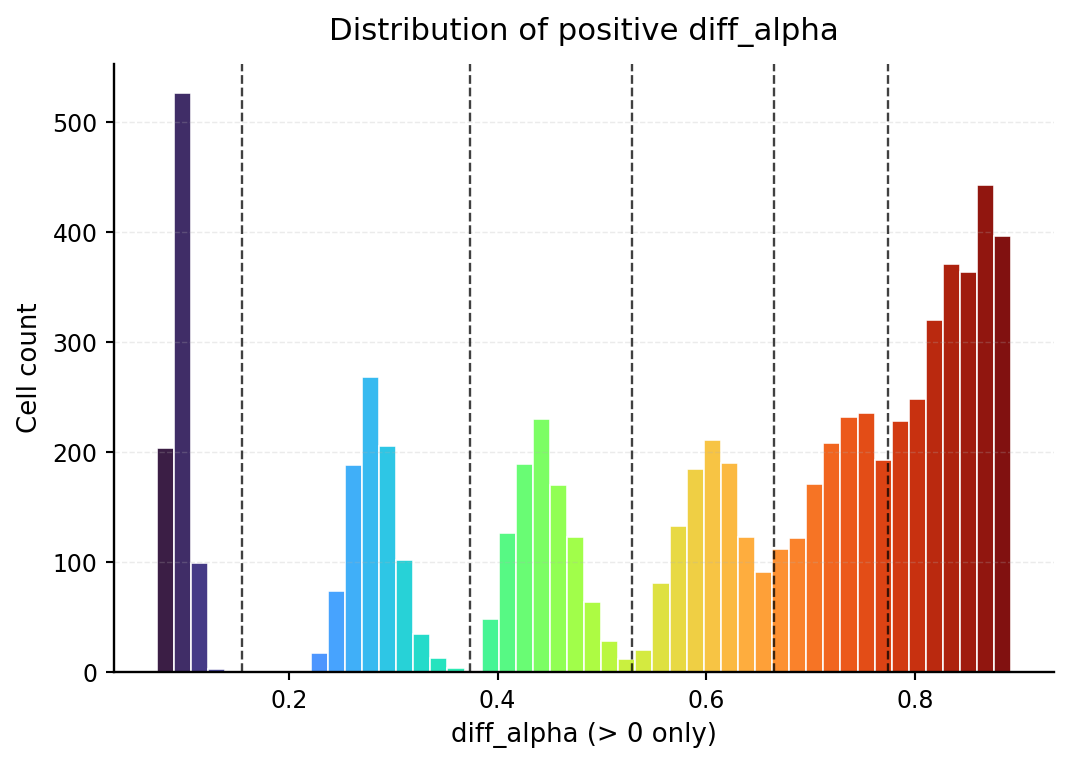

In [11]:
genes = ["COL3A1", "SLC5A5", "AKR1B10", "LCN2", "LGR4", "CAPN8", "RNASE1"]

def extract_counts_hat_df(
    adata,
    genes,
    layer="counts_hat",
    alpha_col="diff_alpha_post",
    diff_col="is_diff",
    only_diff=True,
    log1p=True,
):
    obs = adata.obs.copy()

    genes_ok = [g for g in genes if g in adata.var_names]
    genes_miss = [g for g in genes if g not in adata.var_names]
    if genes_miss:
        print("findgene:", genes_miss)
    if len(genes_ok) == 0:
        raise ValueError("missinggene var_names find")

    alpha = pd.to_numeric(obs[alpha_col], errors="coerce")
    mask = alpha.notna().to_numpy()

    if only_diff and diff_col in obs.columns:
        mask = mask & obs[diff_col].astype(bool).to_numpy()

    ad = adata[mask, genes_ok].copy()
    alpha_sub = pd.to_numeric(ad.obs[alpha_col], errors="coerce").to_numpy()

    X = ad.layers[layer] if layer is not None else ad.X
    if sparse.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)

    if log1p:
        X = np.log1p(np.clip(X, a_min=0, a_max=None))

    df = pd.DataFrame(X, index=ad.obs_names, columns=genes_ok)
    df["diff_alpha_post"] = alpha_sub

    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ["0.00-0.20", "0.20-0.40", "0.40-0.60", "0.60-0.80", "0.80-1.00"]
    df["alpha_bin"] = pd.cut(
        df["diff_alpha_post"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    return df

df = extract_counts_hat_df(
    adata,
    genes=genes,
    layer="counts_hat",
    alpha_col="diff_alpha",   # here diff_alpha
    diff_col="is_diff",
    only_diff=True,
    log1p=True,
)

# :extract_counts_hat_df internal df["diff_alpha_post"]
alpha_all = pd.to_numeric(df["diff_alpha_post"], errors="coerce")
alpha_all = alpha_all[np.isfinite(alpha_all)]

# 0 , bins
eps = 1e-8
alpha_zero = alpha_all[alpha_all <= eps]
alpha_pos  = alpha_all[alpha_all > eps]

print(f": {len(alpha_all)}")
print(f"alpha = 0 : {len(alpha_zero)} ({len(alpha_zero)/len(alpha_all):.2%})")
print(f"alpha > 0 : {len(alpha_pos)} ({len(alpha_pos)/len(alpha_all):.2%})")

print("\n===  alpha (0) ===")
print(alpha_pos.describe())
print(alpha_pos.quantile([0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 1.0]))


def summarize_positive_intervals(alpha_pos, step=0.02):
    """
    ,.
    """
    if len(alpha_pos) == 0:
        return None, None

    maxv = float(alpha_pos.max())
    upper = np.ceil(maxv / step) * step
    edges = np.arange(0, upper + step, step)

    cats = pd.cut(alpha_pos, bins=edges, include_lowest=True, right=True)
    counts = cats.value_counts().sort_index()

    nz = counts[counts > 0].copy()
    nz_df = pd.DataFrame({
        "interval": nz.index.astype(str),
        "count": nz.values
    })

    # 
    merged = []
    current_start = None
    current_end = None

    for iv, cnt in nz.items():
        left = float(iv.left)
        right = float(iv.right)
        if current_start is None:
            current_start = left
            current_end = right
        else:
            # 
            if abs(left - current_end) < 1e-12:
                current_end = right
            else:
                merged.append((current_start, current_end))
                current_start = left
                current_end = right

    if current_start is not None:
        merged.append((current_start, current_end))

    merged_df = pd.DataFrame(merged, columns=["range_start", "range_end"])
    merged_df["range"] = merged_df.apply(
        lambda r: f"({r['range_start']:.2f}, {r['range_end']:.2f}]",
        axis=1
    )

    return nz_df, merged_df


def suggest_bins_by_valleys(alpha_pos, bins=80, smooth_kernel=(1, 2, 3, 2, 1),
                            min_prom_ratio=0.05, min_peak_distance=4):
    """
    , bin .
     0 .
    """
    if len(alpha_pos) == 0:
        return None, None, None, None, None

    hist_counts, hist_edges = np.histogram(alpha_pos, bins=bins)
    centers = (hist_edges[:-1] + hist_edges[1:]) / 2

    ker = np.array(smooth_kernel, dtype=float)
    ker = ker / ker.sum()
    smooth = np.convolve(hist_counts, ker, mode="same")

    prom = max(3, smooth.max() * float(min_prom_ratio))
    peaks, _ = find_peaks(smooth, prominence=prom, distance=min_peak_distance)

    valleys = []
    for p1, p2 in zip(peaks[:-1], peaks[1:]):
        j = p1 + np.argmin(smooth[p1:p2+1])
        valleys.append(j)

    # :,,
    suggested_edges = [float(alpha_pos.min())]
    suggested_edges += [float(hist_edges[j+1]) for j in valleys]
    suggested_edges += [float(alpha_pos.max())]

    return centers, hist_counts, smooth, peaks, suggested_edges


# 1) ""
nz_df, merged_df = summarize_positive_intervals(alpha_pos, step=0.02)

print("\n=== (0.02), ===")
print(nz_df.to_string(index=False))

print("\n===  ===")
print(merged_df[["range"]].to_string(index=False))


# 2)  bin ()
centers, hist_counts, smooth, peaks, suggested_edges = suggest_bins_by_valleys(
    alpha_pos,
    bins=90,
    min_prom_ratio=0.04,
    min_peak_distance=5
)

print("\n===  bin (0) ===")
print([round(x, 4) for x in suggested_edges])

suggested_bins = pd.IntervalIndex.from_breaks(suggested_edges, closed="right")
bin_counts = pd.cut(alpha_pos, bins=suggested_edges, include_lowest=True).value_counts().sort_index()

print("\n===  bins  ===")
print(bin_counts.to_string())


# 3) : +  + 
fig, ax = plt.subplots(figsize=(6.4, 4.6), dpi=170)

n, bins, patches = ax.hist(
    alpha_pos,
    bins=50,
    edgecolor="white",
    linewidth=0.7
)

# 
cmap = plt.cm.turbo
bin_centers = (bins[:-1] + bins[1:]) / 2
norm = plt.Normalize(bin_centers.min(), bin_centers.max())

for c, p in zip(bin_centers, patches):
    p.set_facecolor(cmap(norm(c)))
    p.set_alpha(0.95)

# 
for x in suggested_edges[1:-1]:
    ax.axvline(x, color="black", linestyle="--", linewidth=1.0, alpha=0.75)

# 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(axis="both", which="both", direction="out", width=0.9, labelsize=10)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

ax.set_xlabel("diff_alpha (> 0 only)", fontsize=11)
ax.set_ylabel("Cell count", fontsize=11)
ax.set_title("Distribution of positive diff_alpha", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

In [12]:
NORMAL_NAME = "normal"
PMC_NAME = "PMC_P"
CANCER_NAME = "cancer"

ALPHA_ZERO_BIN = "0"

ALPHA_POS_EDGES = [0.0733, 0.1552, 0.3737, 0.5284, 0.6650, 0.7742, 0.8925]

ALPHA_POS_LABELS = [
    "0.07-0.16",
    "0.16-0.37",
    "0.37-0.53",
    "0.53-0.67",
    "0.67-0.77",
    "0.77-0.89",
]

BIN_ORDER = [ALPHA_ZERO_BIN] + ALPHA_POS_LABELS
DISPLAY_BIN_ORDER = ALPHA_POS_LABELS

GROUP_ORDER = [NORMAL_NAME] + DISPLAY_BIN_ORDER + [CANCER_NAME]
GROUP_ORDER_EXT = [NORMAL_NAME, PMC_NAME] + DISPLAY_BIN_ORDER + [CANCER_NAME]

# 
GROUP_COLORS = {
    NORMAL_NAME: "#8F7CFF",   # 
    PMC_NAME:    "#F28C8C",   # 
    CANCER_NAME: "#46B96C",   # 
    "0.07-0.16": "#BFD9F6",   # 
    "0.16-0.37": "#8EC0EE",   # 
    "0.37-0.53": "#5FA6E5",   # 
    "0.53-0.67": "#357FCA",   # 
    "0.67-0.77": "#1F5DA8",   # 
    "0.77-0.89": "#123D7A",   # 
    ALPHA_ZERO_BIN: "#BFC7D5",  # ()
}

CMAP_MEAN = "viridis"
CMAP_PCT = "YlGnBu"
CMAP_BUBBLE = "magma"

In [13]:
def _style_axis(ax, half_frame=True):
    if half_frame:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    for s in ["left", "bottom"]:
        if s in ax.spines:
            ax.spines[s].set_linewidth(1.0)
    ax.tick_params(axis="both", direction="out", width=0.9, labelsize=10)

def _style_boxplot(bp):
    for box in bp["boxes"]:
        box.set_edgecolor("black")
        box.set_linewidth(1.2)

    for item in bp["whiskers"]:
        item.set_color("black")
        item.set_linewidth(1.2)

    for item in bp["caps"]:
        item.set_color("black")
        item.set_linewidth(1.2)

    for item in bp["medians"]:
        item.set_color("black")
        item.set_linewidth(1.4)

def _get_display_groups(index_like, drop_zero=True):
    groups = [str(x) for x in index_like]
    if drop_zero:
        groups = [g for g in groups if g != ALPHA_ZERO_BIN]
    return groups

def _sort_genes_by_overall_mean(mean_ext, drop_zero=True):
    """
    ()
    """
    display_groups = _get_display_groups(mean_ext.index, drop_zero=drop_zero)
    gene_mean = mean_ext.loc[display_groups].mean(axis=0).sort_values(ascending=False)
    return gene_mean.index.tolist()

def _filter_tables_for_display(mean_ext, pct_ext, drop_zero=True, sort_genes=True):
    display_groups = _get_display_groups(mean_ext.index, drop_zero=drop_zero)
    mean_show = mean_ext.loc[display_groups].copy()
    pct_show = pct_ext.loc[display_groups].copy()

    if sort_genes:
        gene_order = _sort_genes_by_overall_mean(mean_show, drop_zero=False)
        mean_show = mean_show[gene_order]
        pct_show = pct_show[gene_order]
    else:
        gene_order = mean_show.columns.tolist()

    return mean_show, pct_show, gene_order

def _get_group_color(label):
    return GROUP_COLORS.get(label, "#4C78A8")

def exclude_cells_with_initial_layer(
    adata,
    exclude_layers=("6", "9"),
    uid_col="uid",
    layer_col="layer_name",
    order_col=None,   #
):
    obs = adata.obs.copy()

    if uid_col not in obs.columns:
        raise ValueError(f"missingcolumn: {uid_col}")
    if layer_col not in obs.columns:
        raise ValueError(f"missingcolumn: {layer_col}")

    obs[uid_col] = obs[uid_col].astype(str)
    obs[layer_col] = obs[layer_col].astype(str)
    exclude_layers = set(map(str, exclude_layers))

    if order_col is not None and order_col in obs.columns:
        ordv = pd.to_numeric(obs[order_col], errors="coerce")
        obs = obs.assign(_order_=ordv)
        first_idx = (
            obs.reset_index()
               .sort_values([uid_col, "_order_"], ascending=[True, True], kind="stable")
               .groupby(uid_col, sort=False)["index"]
               .first()
        )
    else:
        first_idx = (
            obs.reset_index()
               .groupby(uid_col, sort=False)["index"]
               .first()
        )

    first_obs = obs.loc[first_idx.values, [uid_col, layer_col]].copy()
    bad_uids = set(first_obs.loc[first_obs[layer_col].isin(exclude_layers), uid_col])

    keep_mask = ~obs[uid_col].isin(bad_uids).to_numpy()
    return adata[keep_mask].copy(), bad_uids, first_obs


def extract_real_counts_df(
    adata,
    genes,
    layer="counts",
    log1p=True,
    group_name=NORMAL_NAME,
):
    genes_ok = [g for g in genes if g in adata.var_names]
    genes_miss = [g for g in genes if g not in adata.var_names]
    if genes_miss:
        print(f"{group_name} findgene:", genes_miss)

    if len(genes_ok) == 0:
        raise ValueError(f"{group_name} missinggene var_names find")

    X = adata[:, genes_ok].layers[layer] if layer is not None else adata[:, genes_ok].X
    if sparse.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)

    if log1p:
        X = np.log1p(np.clip(X, a_min=0, a_max=None))

    df = pd.DataFrame(X, index=adata.obs_names, columns=genes_ok)
    df["group"] = group_name
    return df


def extract_counts_hat_df(
    adata,
    genes,
    layer="counts_hat",
    alpha_col="diff_alpha",
    diff_col="is_diff",
    only_diff=True,
    log1p=True,
    eps=1e-8,
):
    obs = adata.obs.copy()

    genes_ok = [g for g in genes if g in adata.var_names]
    genes_miss = [g for g in genes if g not in adata.var_names]
    if genes_miss:
        print("findgene:", genes_miss)
    if len(genes_ok) == 0:
        raise ValueError("missinggene var_names find")

    alpha = pd.to_numeric(obs[alpha_col], errors="coerce")
    mask = alpha.notna().to_numpy()

    if only_diff and diff_col in obs.columns:
        mask = mask & obs[diff_col].astype(bool).to_numpy()

    ad = adata[mask, genes_ok].copy()
    alpha_sub = pd.to_numeric(ad.obs[alpha_col], errors="coerce").to_numpy()

    X = ad.layers[layer] if layer is not None else ad.X
    if sparse.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)

    if log1p:
        X = np.log1p(np.clip(X, a_min=0, a_max=None))

    df = pd.DataFrame(X, index=ad.obs_names, columns=genes_ok)
    df["alpha_value"] = alpha_sub

    alpha_bin = pd.Series(index=df.index, dtype="object")

    zero_mask = np.isfinite(alpha_sub) & (alpha_sub <= eps)
    pos_mask = np.isfinite(alpha_sub) & (alpha_sub > eps)

    alpha_bin.loc[df.index[zero_mask]] = ALPHA_ZERO_BIN

    if pos_mask.sum() > 0:
        cut = pd.cut(
            alpha_sub[pos_mask],
            bins=ALPHA_POS_EDGES,
            labels=ALPHA_POS_LABELS,
            include_lowest=True,
            right=True
        )
        alpha_bin.loc[df.index[pos_mask]] = cut.astype(str)

    df["alpha_bin"] = pd.Categorical(alpha_bin, categories=BIN_ORDER, ordered=True)
    return df


# =========================
# 3) 
# =========================
def calc_group_summary(df, genes, group_col):
    mean_tab = df.groupby(group_col, observed=True)[genes].mean()
    med_tab  = df.groupby(group_col, observed=True)[genes].median()
    pct_tab  = df.groupby(group_col, observed=True)[genes].apply(
        lambda x: (x > 0).mean(axis=0)
    )
    return mean_tab, med_tab, pct_tab

def _reindex_group_df(tab, group_order):
    out = tab.copy()
    out.index = out.index.astype(str)
    idx = [x for x in group_order if x in out.index.tolist()]
    return out.reindex(idx)

def build_extended_heatmap_tables_with_pmc(
    df_virtual,
    adata_real_nor,
    adata_pmc11,
    adata_real_can,
    genes,
    group_col="alpha_bin",
    group_order=None,
):
    genes_ok = [g for g in genes if g in df_virtual.columns]

    if group_order is None:
        if group_col == "alpha_bin":
            group_order = BIN_ORDER
        else:
            group_order = sorted(df_virtual[group_col].dropna().astype(str).unique().tolist())

    mean_tab, med_tab, pct_tab = calc_group_summary(df_virtual, genes_ok, group_col=group_col)
    mean_tab = _reindex_group_df(mean_tab, group_order)
    pct_tab  = _reindex_group_df(pct_tab, group_order)

    df_real_nor = extract_real_counts_df(
        adata_real_nor, genes_ok, layer="counts", log1p=True, group_name=NORMAL_NAME
    )
    df_pmc = extract_real_counts_df(
        adata_pmc11, genes_ok, layer="counts", log1p=True, group_name=PMC_NAME
    )
    df_real_can = extract_real_counts_df(
        adata_real_can, genes_ok, layer="counts", log1p=True, group_name=CANCER_NAME
    )

    mean_nor = pd.DataFrame([df_real_nor[genes_ok].mean(axis=0)], index=[NORMAL_NAME])
    mean_pmc = pd.DataFrame([df_pmc[genes_ok].mean(axis=0)], index=[PMC_NAME])
    mean_can = pd.DataFrame([df_real_can[genes_ok].mean(axis=0)], index=[CANCER_NAME])

    pct_nor = pd.DataFrame([(df_real_nor[genes_ok] > 0).mean(axis=0)], index=[NORMAL_NAME])
    pct_pmc = pd.DataFrame([(df_pmc[genes_ok] > 0).mean(axis=0)], index=[PMC_NAME])
    pct_can = pd.DataFrame([(df_real_can[genes_ok] > 0).mean(axis=0)], index=[CANCER_NAME])

    group_order_ext_full = [NORMAL_NAME, PMC_NAME] + list(group_order) + [CANCER_NAME]

    mean_ext = pd.concat([mean_nor, mean_pmc, mean_tab, mean_can], axis=0).reindex(group_order_ext_full)
    pct_ext  = pd.concat([pct_nor, pct_pmc, pct_tab, pct_can], axis=0).reindex(group_order_ext_full)

    return mean_ext, pct_ext, df_real_nor, df_pmc, df_real_can, group_order_ext_full


# =========================
# 4) 
# =========================
def plot_group_heatmaps_with_real_and_pmc(
    mean_ext,
    pct_ext,
    title_mid="alpha bins",
    figsize=(12.8, 4.8),
    dpi=170,
    sort_genes=True,
    drop_zero=True,
):
    mean_show, pct_show, gene_order = _filter_tables_for_display(
        mean_ext, pct_ext, drop_zero=drop_zero, sort_genes=sort_genes
    )

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

    ax = axes[0]
    im1 = ax.imshow(mean_show.T.values, aspect="auto", cmap=CMAP_MEAN)
    ax.set_title("Mean log1p expression", fontsize=13, pad=8)
    ax.set_xticks(range(mean_show.shape[0]))
    ax.set_xticklabels(mean_show.index, rotation=35, ha="right")
    ax.set_yticks(range(mean_show.shape[1]))
    ax.set_yticklabels(mean_show.columns)
    cbar1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    cbar1.set_label("Mean expression")
    _style_axis(ax, half_frame=False)

    ax = axes[1]
    im2 = ax.imshow(pct_show.T.values, aspect="auto", vmin=0, vmax=1, cmap=CMAP_PCT)
    ax.set_title("Expression fraction", fontsize=13, pad=8)
    ax.set_xticks(range(pct_show.shape[0]))
    ax.set_xticklabels(pct_show.index, rotation=35, ha="right")
    ax.set_yticks(range(pct_show.shape[1]))
    ax.set_yticklabels(pct_show.columns)
    cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    cbar2.set_label("Fraction > 0")
    _style_axis(ax, half_frame=False)

    plt.suptitle(f"{NORMAL_NAME} | {PMC_NAME} | {title_mid} | {CANCER_NAME}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================
# 5) 
# =========================
def plot_group_bubble_with_real_and_pmc(
    mean_ext,
    pct_ext,
    title_mid="alpha bins",
    figsize=(12.5, 5.2),
    dpi=170,
    sort_genes=True,
    drop_zero=True,
    size_min=30,
    size_scale=420,
):
    mean_show, pct_show, gene_order = _filter_tables_for_display(
        mean_ext, pct_ext, drop_zero=drop_zero, sort_genes=sort_genes
    )

    groups = mean_show.index.tolist()
    genes = mean_show.columns.tolist()

    rows = []
    for ix, g in enumerate(groups):
        for iy, gene in enumerate(genes):
            rows.append({
                "group": g,
                "gene": gene,
                "x": ix,
                "y": iy,
                "mean_expr": mean_show.loc[g, gene],
                "pct_expr": pct_show.loc[g, gene],
            })
    long_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sca = ax.scatter(
        long_df["x"],
        long_df["y"],
        s=size_min + size_scale * long_df["pct_expr"].values,
        c=long_df["mean_expr"].values,
        cmap=CMAP_BUBBLE,
        alpha=0.95,
        edgecolors="black",
        linewidths=0.35
    )

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, rotation=35, ha="right")
    ax.set_yticks(range(len(genes)))
    ax.set_yticklabels(genes)
    ax.invert_yaxis()
    ax.set_title("Bubble plot: color = mean, size = fraction", fontsize=13, pad=8)
    _style_axis(ax, half_frame=False)

    cbar = plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean expression")

    plt.tight_layout()
    plt.show()


# =========================
# 6) module score 
# =========================
def make_module_score_df(
    df_virtual,
    df_real_nor,
    df_pmc,
    df_real_can,
    genes,
    group_col="alpha_bin",
    group_order_ext=None,
):
    genes_ok = [g for g in genes if g in df_virtual.columns]
    rows = []

    ms_nor = df_real_nor[genes_ok].mean(axis=1)
    rows += [{"group": NORMAL_NAME, "module_score": float(v)} for v in ms_nor]

    ms_pmc = df_pmc[genes_ok].mean(axis=1)
    rows += [{"group": PMC_NAME, "module_score": float(v)} for v in ms_pmc]

    tmp = df_virtual.copy()
    tmp[group_col] = tmp[group_col].astype(str)
    tmp = tmp[tmp[group_col].notna()].copy()
    tmp["module_score"] = tmp[genes_ok].mean(axis=1)
    rows += tmp[[group_col, "module_score"]].rename(columns={group_col: "group"}).to_dict("records")

    ms_can = df_real_can[genes_ok].mean(axis=1)
    rows += [{"group": CANCER_NAME, "module_score": float(v)} for v in ms_can]

    stat_df = pd.DataFrame(rows)

    if group_order_ext is None:
        middle = sorted(tmp[group_col].dropna().unique().tolist())
        group_order_ext = [NORMAL_NAME, PMC_NAME] + middle + [CANCER_NAME]

    return stat_df, group_order_ext


# =========================
# 7) module score 
# =========================
def plot_module_score_boxplot_with_pmc(
    df_virtual,
    df_real_nor,
    df_pmc,
    df_real_can,
    genes,
    group_col="alpha_bin",
    group_order_ext=None,
    figsize=(9.8, 5.0),
    dpi=170,
    show_fliers=False,
    drop_zero=True,
):
    stat_df, group_order_ext = make_module_score_df(
        df_virtual, df_real_nor, df_pmc, df_real_can,
        genes, group_col=group_col, group_order_ext=group_order_ext
    )

    labels = [g for g in group_order_ext if g in stat_df["group"].unique()]
    if drop_zero:
        labels = [g for g in labels if g != ALPHA_ZERO_BIN]

    data_list = [stat_df.loc[stat_df["group"] == g, "module_score"].dropna().values for g in labels]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    bp = ax.boxplot(
        data_list,
        tick_labels=labels,
        patch_artist=True,
        showfliers=show_fliers
    )

    for patch, lab in zip(bp["boxes"], labels):
        patch.set_facecolor(_get_group_color(lab))
        patch.set_alpha(0.95)

    _style_boxplot(bp)
    _style_axis(ax, half_frame=True)

    ax.set_ylabel("Module score")
    ax.set_xlabel("")
    ax.set_title("7-gene module score", fontsize=13, pad=8)
    ax.tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()
    return stat_df


# =========================
# 8) module score  / ridge 
# =========================
def plot_module_score_ridge_with_pmc(
    df_virtual,
    df_real_nor,
    df_pmc,
    df_real_can,
    genes,
    group_col="alpha_bin",
    group_order_ext=None,
    figsize=(10.5, 6.2),
    dpi=170,
    drop_zero=True,
    ridge_height=0.8,
):
    stat_df, group_order_ext = make_module_score_df(
        df_virtual, df_real_nor, df_pmc, df_real_can,
        genes, group_col=group_col, group_order_ext=group_order_ext
    )

    labels = [g for g in group_order_ext if g in stat_df["group"].unique()]
    if drop_zero:
        labels = [g for g in labels if g != ALPHA_ZERO_BIN]

    all_vals = stat_df["module_score"].dropna().values
    x_grid = np.linspace(all_vals.min() - 0.1, all_vals.max() + 0.1, 450)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    #  normal ,cancer 
    n_lab = len(labels)
    for i, lab in enumerate(labels):
        vals = stat_df.loc[stat_df["group"] == lab, "module_score"].dropna().values
        if len(vals) == 0:
            continue

        base_y = n_lab - 1 - i
        color = _get_group_color(lab)

        if len(vals) >= 3 and np.std(vals) > 1e-8:
            kde = gaussian_kde(vals)
            y = kde(x_grid)
            y = y / y.max() * ridge_height
            ax.fill_between(x_grid, base_y, base_y + y, color=color, alpha=0.65, linewidth=0)
            ax.plot(x_grid, base_y + y, color=color, linewidth=1.8)
        else:
            mu = np.mean(vals)
            ax.plot([mu, mu], [base_y, base_y + ridge_height * 0.8], color=color, linewidth=2.0)

        ax.hlines(base_y, x_grid.min(), x_grid.max(), color="black", linewidth=0.45, alpha=0.25)

    ax.set_yticks(range(n_lab))
    ax.set_yticklabels(labels[::-1])
    ax.set_xlabel("Module score")
    ax.set_ylabel("")
    ax.set_title("7-gene module score ridge plot", fontsize=13, pad=8)

    _style_axis(ax, half_frame=True)
    plt.tight_layout()
    plt.show()


# =========================
# 9) gene
# =========================
def plot_gene_boxplots_with_real_and_pmc(
    df_virtual,
    df_real_nor,
    df_pmc,
    df_real_can,
    genes,
    group_col="alpha_bin",
    group_order_ext=None,
    ncol=3,
    figsize_per_panel=(4.5, 3.5),
    dpi=170,
    show_fliers=False,
    drop_zero=True,
):
    genes_ok = [g for g in genes if g in df_virtual.columns]
    n = len(genes_ok)
    nrow = math.ceil(n / ncol)

    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=(figsize_per_panel[0] * ncol, figsize_per_panel[1] * nrow),
        dpi=dpi
    )
    axes = np.array(axes).reshape(-1)

    dfp = df_virtual.copy()
    dfp[group_col] = dfp[group_col].astype(str)

    if group_order_ext is None:
        middle = sorted(dfp[group_col].dropna().unique().tolist())
        group_order_ext = [NORMAL_NAME, PMC_NAME] + middle + [CANCER_NAME]

    middle_order = [g for g in group_order_ext if g not in [NORMAL_NAME, PMC_NAME, CANCER_NAME]]
    if drop_zero:
        middle_order = [g for g in middle_order if g != ALPHA_ZERO_BIN]

    for ax, g in zip(axes, genes_ok):
        data_list = []
        labels = []

        vals = pd.to_numeric(df_real_nor[g], errors="coerce").dropna().values
        if len(vals) > 0:
            data_list.append(vals); labels.append(NORMAL_NAME)

        vals = pd.to_numeric(df_pmc[g], errors="coerce").dropna().values
        if len(vals) > 0:
            data_list.append(vals); labels.append(PMC_NAME)

        for b in middle_order:
            vals = pd.to_numeric(dfp.loc[dfp[group_col] == b, g], errors="coerce").dropna().values
            if len(vals) > 0:
                data_list.append(vals); labels.append(b)

        vals = pd.to_numeric(df_real_can[g], errors="coerce").dropna().values
        if len(vals) > 0:
            data_list.append(vals); labels.append(CANCER_NAME)

        if len(data_list) == 0:
            ax.axis("off")
            continue

        bp = ax.boxplot(
            data_list,
            tick_labels=labels,
            patch_artist=True,
            showfliers=show_fliers
        )

        for patch, lab in zip(bp["boxes"], labels):
            patch.set_facecolor(_get_group_color(lab))
            patch.set_alpha(0.95)

        _style_boxplot(bp)
        _style_axis(ax, half_frame=True)

        ax.set_title(g, fontsize=12, pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("log1p(expression)")
        ax.tick_params(axis="x", rotation=35)

    for j in range(len(genes_ok), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# 10) 
# =========================
from scipy.spatial.distance import jensenshannon

def rank_pmc_module_js(
    df_virtual,
    df_pmc,
    genes,
    group_col="alpha_bin",
    score_col="module_score",
    drop_zero=True,
    alpha_zero_bin=None,
    n_bins=60,
    value_range=None,
):
    dfv = df_virtual.copy()
    dfp = df_pmc.copy()

    genes_ok = [g for g in genes if g in dfv.columns and g in dfp.columns]
    if len(genes_ok) == 0:
        raise ValueError("genes missinggene.")

    dfv[group_col] = dfv[group_col].astype(str)

    # missing module_score 
    if score_col not in dfv.columns:
        dfv[score_col] = dfv[genes_ok].mean(axis=1)
    if score_col not in dfp.columns:
        dfp[score_col] = dfp[genes_ok].mean(axis=1)

    dfv[score_col] = pd.to_numeric(dfv[score_col], errors="coerce")
    dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")

    pmc_score = dfp[score_col].dropna().to_numpy(dtype=float)
    if len(pmc_score) == 0:
        raise ValueError("df_pmc  module_score is empty.")

    # 
    if value_range is None:
        all_scores = np.concatenate([
            dfv[score_col].dropna().to_numpy(dtype=float),
            pmc_score
        ])
        lo, hi = np.min(all_scores), np.max(all_scores)
        pad = max((hi - lo) * 0.02, 1e-8)
        value_range = (lo - pad, hi + pad)

    edges = np.linspace(value_range[0], value_range[1], n_bins + 1)
    eps = 1e-12

    # PMC 
    pmc_hist, _ = np.histogram(pmc_score, bins=edges, density=False)
    pmc_prob = pmc_hist.astype(float) + eps
    pmc_prob = pmc_prob / pmc_prob.sum()

    rows = []
    for grp, sub in dfv.groupby(group_col, observed=True):
        grp = str(grp)

        if drop_zero and alpha_zero_bin is not None and grp == str(alpha_zero_bin):
            continue

        x = sub[score_col].dropna().to_numpy(dtype=float)
        if len(x) < 5:
            continue

        hist, _ = np.histogram(x, bins=edges, density=False)
        prob = hist.astype(float) + eps
        prob = prob / prob.sum()

        js_div = float(jensenshannon(prob, pmc_prob, base=2.0) ** 2)

        rows.append({
            "group": grp,
            "n_cells": len(x),
            "js_divergence": js_div,              # lower = more similar
            "js_similarity": 1 - js_div,          # higher = more similar
            "group_mean": float(np.mean(x)),
            "pmc_mean": float(np.mean(pmc_score)),
            "group_median": float(np.median(x)),
            "pmc_median": float(np.median(pmc_score)),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out, edges

    out = out.sort_values("js_divergence", ascending=True).reset_index(drop=True)
    return out, edges

排除初始 layer_name 为 6/9 的 uid 数量: 1549
过滤后剩余细胞数: 10468


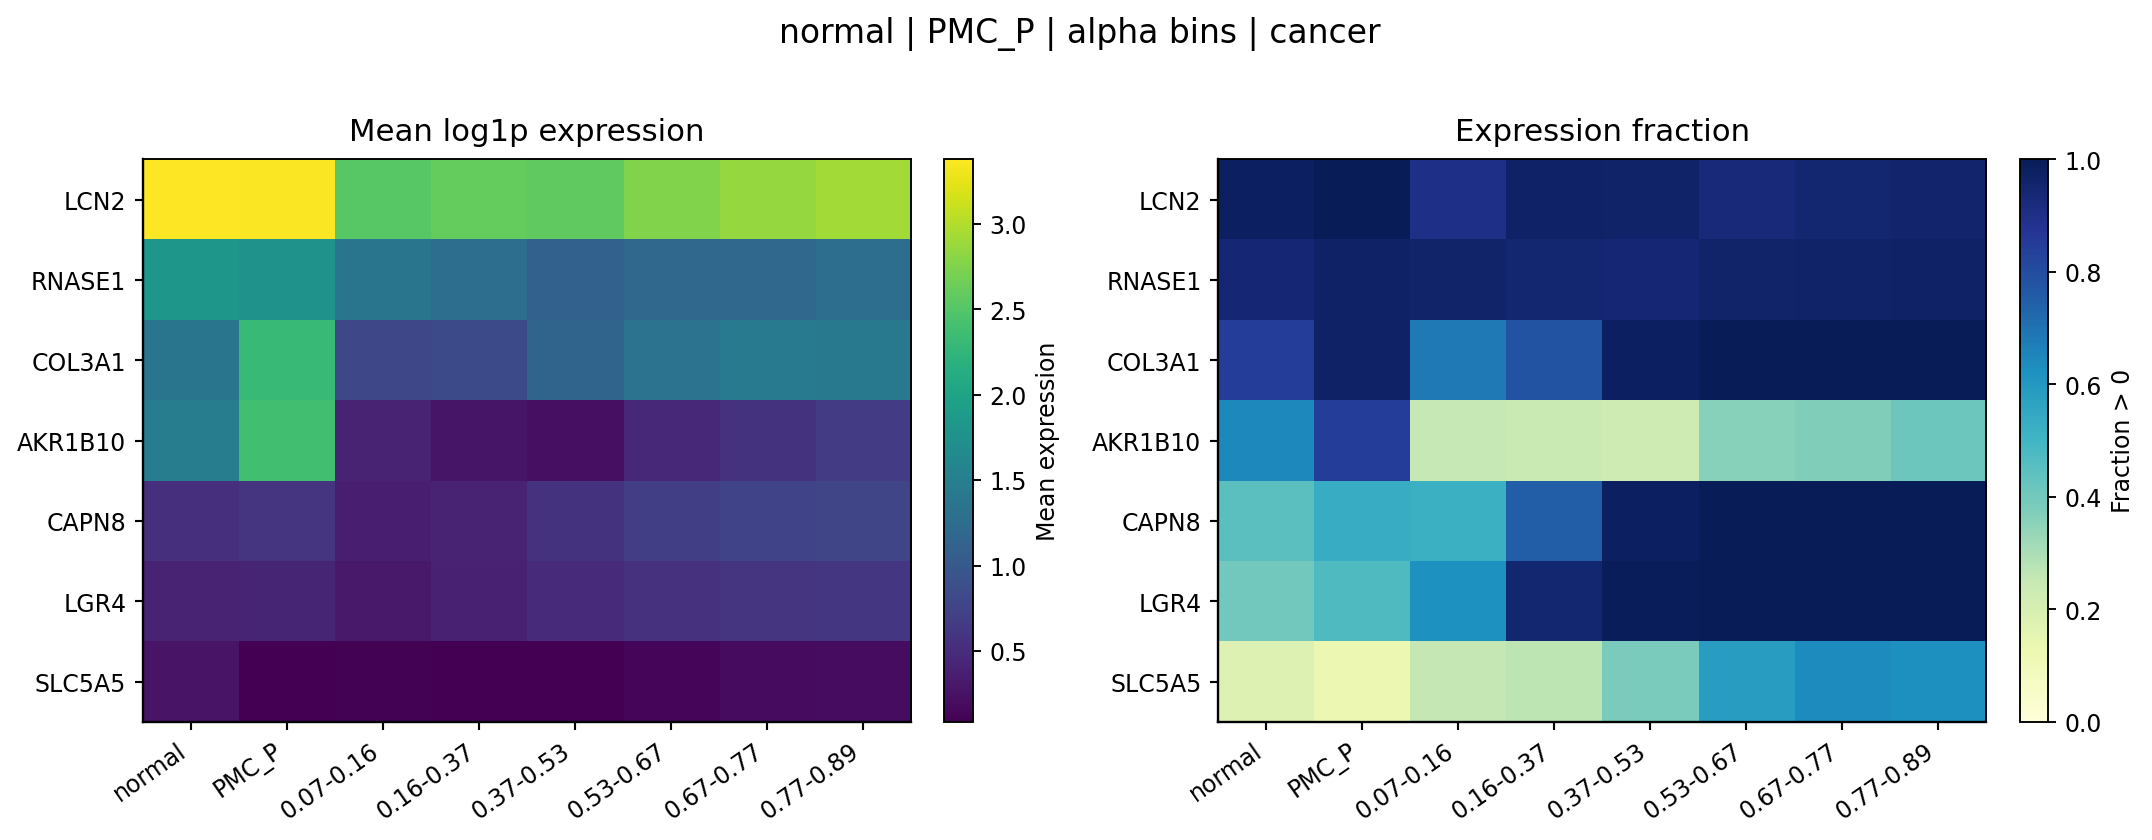

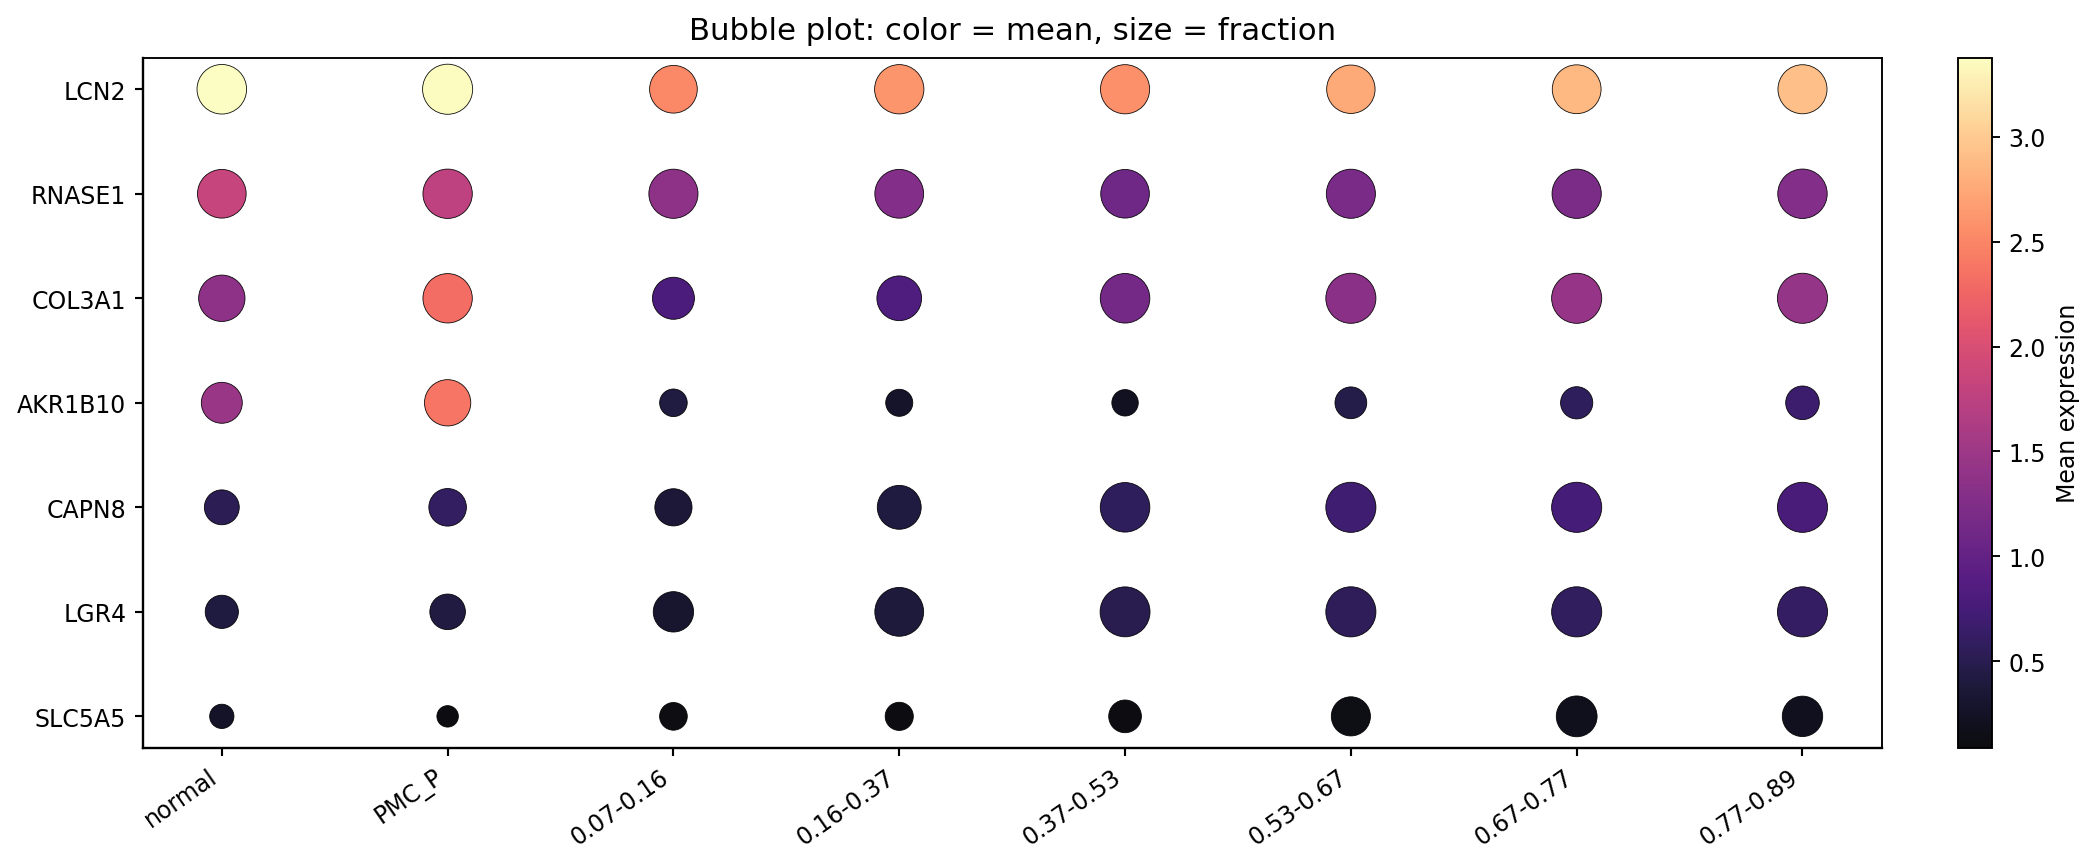

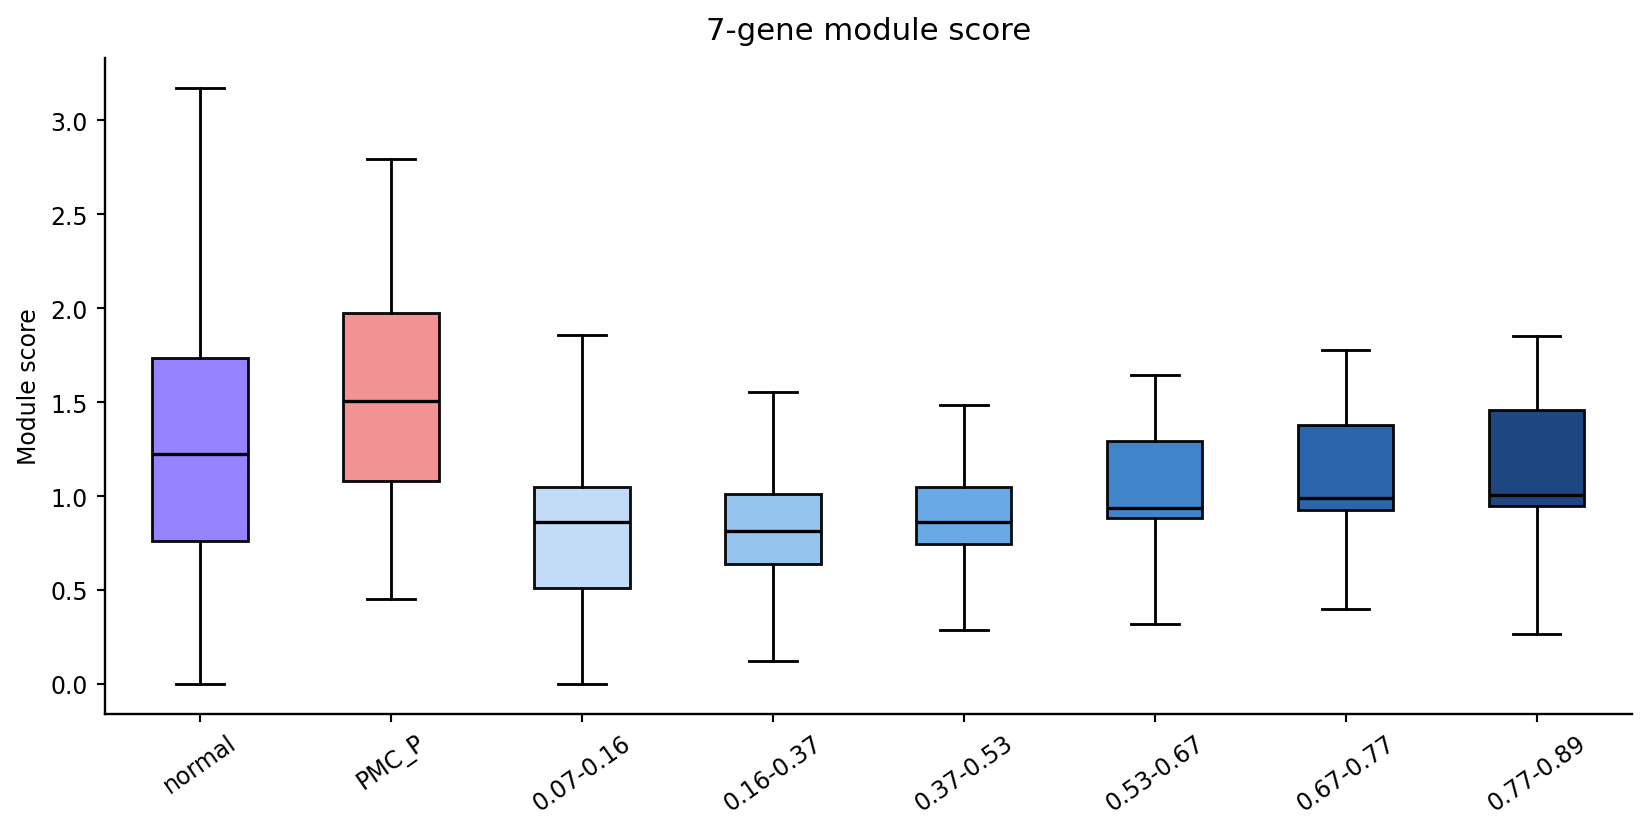

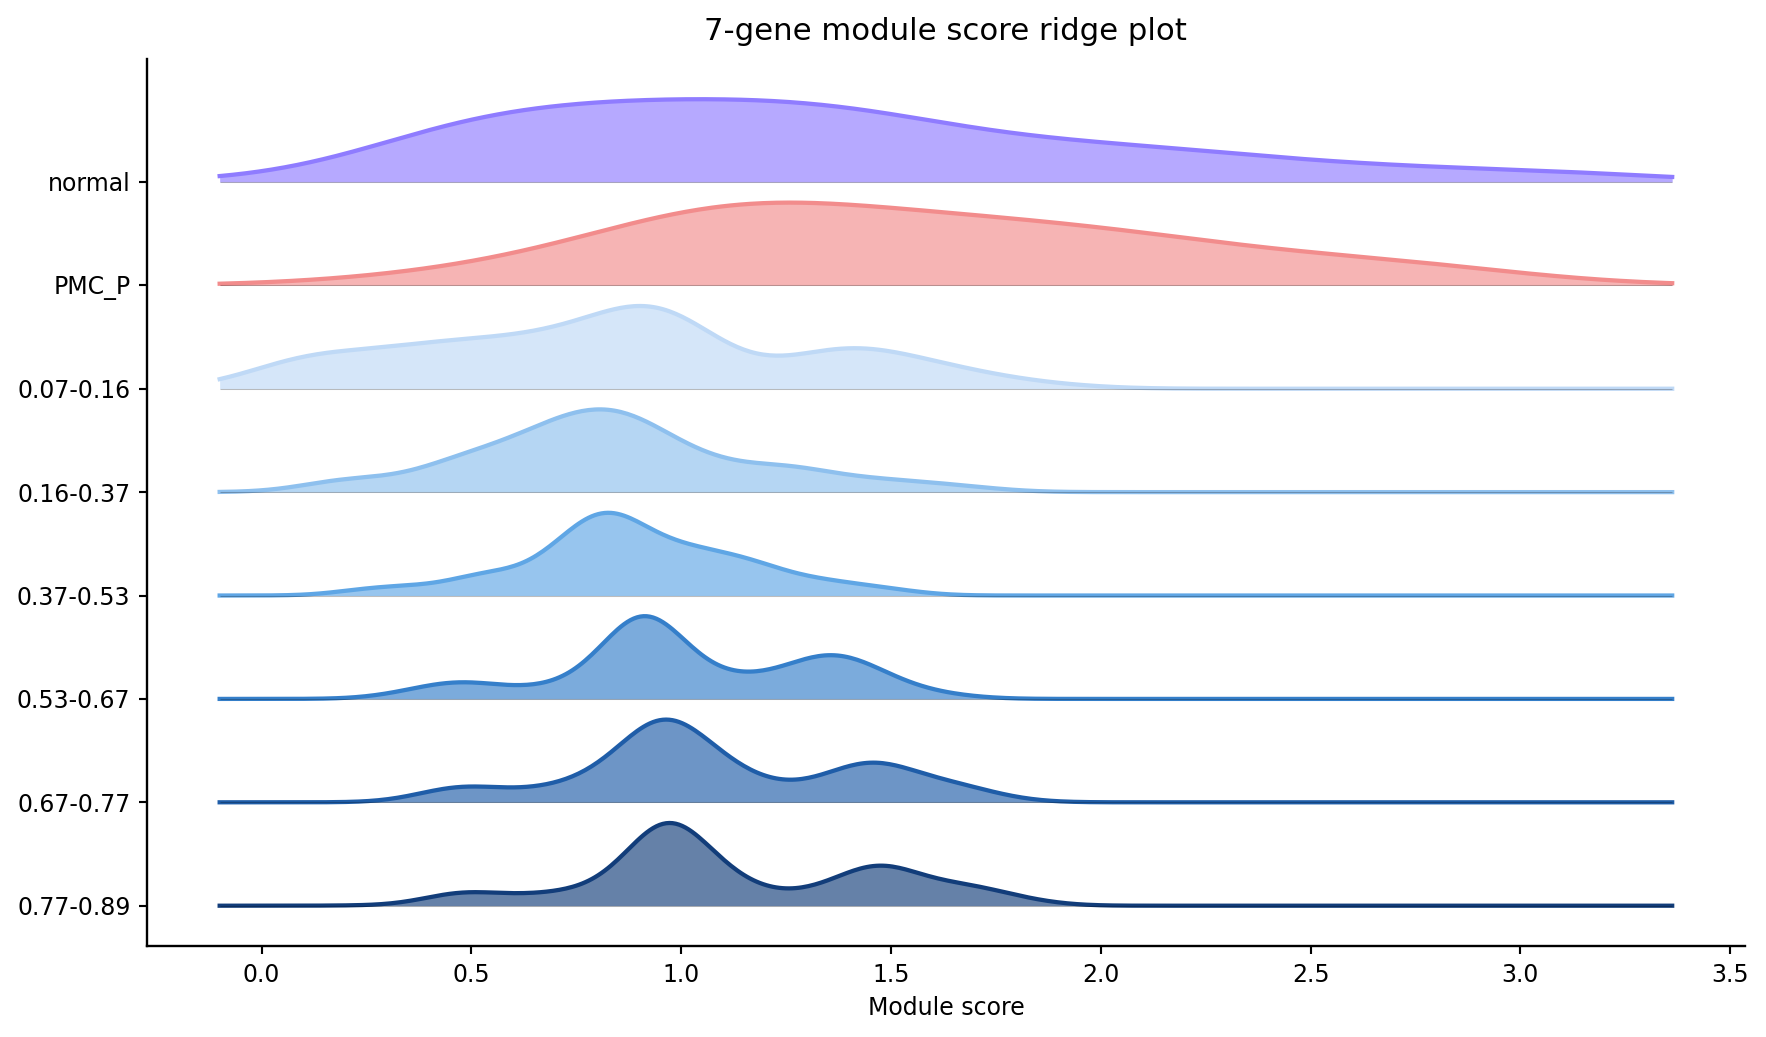

       group  n_cells  js_divergence  js_similarity  group_mean  pmc_mean  \
0  0.77-0.89      779       0.406618       0.593382    1.121538  1.561822   
1  0.67-0.77      425       0.416469       0.583531    1.080588  1.561822   
2  0.53-0.67      381       0.496577       0.503423    1.017188  1.561822   
3  0.16-0.37      386       0.527815       0.472185    0.836994  1.561822   
4  0.07-0.16      399       0.536333       0.463667    0.840732  1.561822   
5  0.37-0.53      384       0.547583       0.452417    0.884766  1.561822   

   group_median  pmc_median  
0      1.005064    1.506472  
1      0.991517    1.506472  
2      0.937570    1.506472  
3      0.812688    1.506472  
4      0.861941    1.506472  
5      0.861146    1.506472  


/tmp/ipykernel_3449759/3236402940.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm_r")


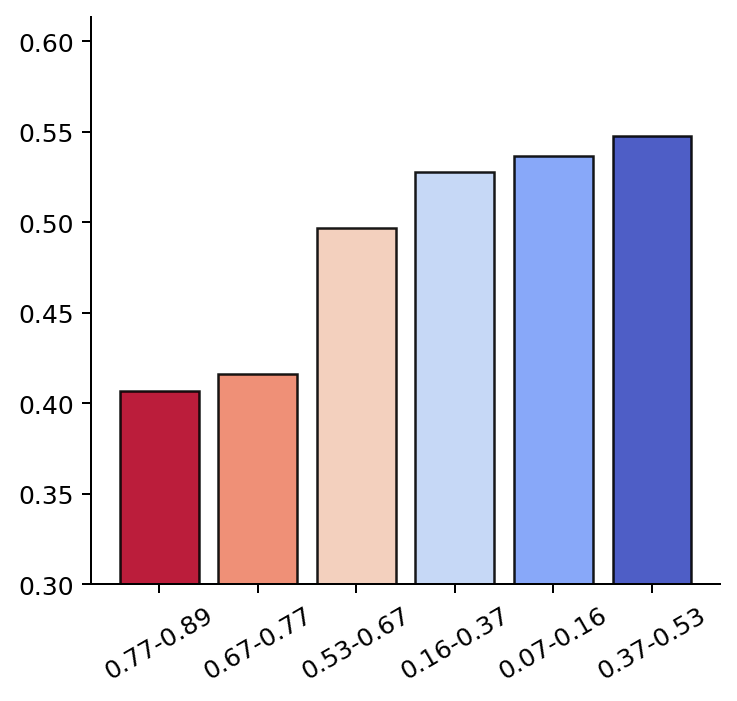

       group  n_cells  js_divergence  js_similarity  group_mean  pmc_mean  \
0  0.77-0.89      779       0.406618       0.593382    1.121538  1.561822   
1  0.67-0.77      425       0.416469       0.583531    1.080588  1.561822   
2  0.53-0.67      381       0.496577       0.503423    1.017188  1.561822   
3  0.16-0.37      386       0.527815       0.472185    0.836994  1.561822   
4  0.07-0.16      399       0.536333       0.463667    0.840732  1.561822   
5  0.37-0.53      384       0.547583       0.452417    0.884766  1.561822   

   group_median  pmc_median  
0      1.005064    1.506472  
1      0.991517    1.506472  
2      0.937570    1.506472  
3      0.812688    1.506472  
4      0.861941    1.506472  
5      0.861146    1.506472  


In [14]:
genes = [ "AKR1B10", "LCN2", "LGR4", "CAPN8", "COL3A1", "SLC5A5", "RNASE1"]

adata_stat, bad_uids, first_obs = exclude_cells_with_initial_layer(
    adata,
    exclude_layers=("6", "9"),
    uid_col="uid",
    layer_col="layer_name",
    order_col="born_step",   # here frame / t,
)

print(f" layer_name  6/9  uid : {len(bad_uids)}")
print(f": {adata_stat.n_obs}")

df_virtual_alpha = extract_counts_hat_df(
    adata_stat,
    genes,
    layer="counts_hat",
    alpha_col="diff_alpha",
    diff_col="is_diff",
    only_diff=True,
    log1p=True,
)
mean_ext_a, pct_ext_a, df_real_nor, df_pmc, df_real_can, ALPHA_GROUP_ORDER_EXT = \
    build_extended_heatmap_tables_with_pmc(
        df_virtual=df_virtual_alpha,
        adata_real_nor=adata_real_nor,
        adata_pmc11=adata_pmc11,
        adata_real_can=adata_real_can,
        genes=genes,
        group_col="alpha_bin",
        group_order=BIN_ORDER,
    )

# # ( 0)
# plot_group_heatmaps_with_real_and_pmc(
#     mean_ext_a,
#     pct_ext_a,
#     title_mid="alpha bins",
#     sort_genes=True,
#     drop_zero=True,
# )

# # ( 0)
# plot_group_bubble_with_real_and_pmc(
#     mean_ext_a,
#     pct_ext_a,
#     title_mid="alpha bins",
#     sort_genes=True,
#     drop_zero=True,
# )

mean_ext_no_can = mean_ext_a.drop(index=CANCER_NAME, errors="ignore")
pct_ext_no_can  = pct_ext_a.drop(index=CANCER_NAME, errors="ignore")

plot_group_heatmaps_with_real_and_pmc(
    mean_ext_no_can,
    pct_ext_no_can,
    title_mid="alpha bins",
    sort_genes=True,
    drop_zero=True,
)

plot_group_bubble_with_real_and_pmc(
    mean_ext_no_can,
    pct_ext_no_can,
    title_mid="alpha bins",
    sort_genes=True,
    drop_zero=True,
)


group_order_no_can = [NORMAL_NAME, PMC_NAME] + BIN_ORDER

stat_df = plot_module_score_boxplot_with_pmc(
    df_virtual=df_virtual_alpha,
    df_real_nor=df_real_nor,
    df_pmc=df_pmc,
    df_real_can=df_real_can,   # here,
    genes=genes,
    group_col="alpha_bin",
    group_order_ext=group_order_no_can,
    show_fliers=False,
    drop_zero=True,
)

plot_module_score_ridge_with_pmc(
    df_virtual=df_virtual_alpha,
    df_real_nor=df_real_nor,
    df_pmc=df_pmc,
    df_real_can=df_real_can,   # 
    genes=genes,
    group_col="alpha_bin",
    group_order_ext=group_order_no_can,
    drop_zero=True,
)

# # module score ( 0)
# stat_df = plot_module_score_boxplot_with_pmc(
#     df_virtual=df_virtual_alpha,
#     df_real_nor=df_real_nor,
#     df_pmc=df_pmc,
#     df_real_can=df_real_can,
#     genes=genes,
#     group_col="alpha_bin",
#     group_order_ext=[NORMAL_NAME, PMC_NAME] + BIN_ORDER + [CANCER_NAME],
#     show_fliers=False,
#     drop_zero=True,
# )

# # module score ridge ( 0)
# plot_module_score_ridge_with_pmc(
#     df_virtual=df_virtual_alpha,
#     df_real_nor=df_real_nor,
#     df_pmc=df_pmc,
#     df_real_can=df_real_can,
#     genes=genes,
#     group_col="alpha_bin",
#     group_order_ext=[NORMAL_NAME, PMC_NAME] + BIN_ORDER + [CANCER_NAME],
#     drop_zero=True,
# )

# # gene( 0)
# plot_gene_boxplots_with_real_and_pmc(
#     df_virtual=df_virtual_alpha,
#     df_real_nor=df_real_nor,
#     df_pmc=df_pmc,
#     df_real_can=df_real_can,
#     genes=genes,
#     group_col="alpha_bin",
#     group_order_ext=[NORMAL_NAME, PMC_NAME] + BIN_ORDER + [CANCER_NAME],
#     show_fliers=False,
#     drop_zero=True,
# )

if "module_score" not in df_virtual_alpha.columns:
    df_virtual_alpha = df_virtual_alpha.copy()
    df_virtual_alpha["module_score"] = df_virtual_alpha[genes].mean(axis=1)

if "module_score" not in df_pmc.columns:
    df_pmc = df_pmc.copy()
    df_pmc["module_score"] = df_pmc[genes].mean(axis=1)

global_scores = pd.concat(
    [df_virtual_alpha["module_score"], df_pmc["module_score"]],
    axis=0
).dropna()

global_range = (global_scores.min(), global_scores.max())

sim_js, edges = rank_pmc_module_js(
    df_virtual=df_virtual_alpha,
    df_pmc=df_pmc,
    genes=genes,
    group_col="alpha_bin",
    drop_zero=True,
    alpha_zero_bin=ALPHA_ZERO_BIN,
    n_bins=60,
    value_range=global_range,
)

print(sim_js)

from matplotlib import cm
def plot_module_js_bar(js_df, figsize=(4.2, 4), dpi=180):
    plot_df = js_df.copy()

    if "js_divergence" not in plot_df.columns:
        raise ValueError("js_df missing 'js_divergence' column.")

    plot_df["js_divergence"] = pd.to_numeric(plot_df["js_divergence"], errors="coerce")
    plot_df = plot_df.dropna(subset=["js_divergence"]).copy()
    plot_df = plot_df.sort_values("js_divergence", ascending=True).reset_index(drop=True)

    n = len(plot_df)
    if n == 0:
        raise ValueError("missing.")

    cmap = cm.get_cmap("coolwarm_r")
    if n == 1:
        colors = [cmap(0.02)]
    else:
        colors = [cmap(i / (n - 1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.bar(
        plot_df["group"],
        plot_df["js_divergence"],
        color=colors,
        edgecolor="black",
        linewidth=1.0,
        alpha=0.9,
    )

    # ax.set_title("Module-score JS divergence to PMC_P", fontsize=14, pad=10)
    # ax.set_xlabel("alpha stage")
    # ax.set_ylabel("lower = more similar")
    ax.tick_params(axis="x", rotation=30)

    ymax = plot_df["js_divergence"].max()
    ax.set_ylim(0.3, ymax * 1.12 if ymax > 0.3 else 0.35)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

    plt.tight_layout()
    plt.show()
    return plot_df

plot_df = plot_module_js_bar(sim_js)
# :
# plot_df = plot_module_js_similarity_bar(sim_js)

print(plot_df[[
    "group", "n_cells",
    "js_divergence",
    "js_similarity",
    "group_mean",
    "pmc_mean",
    "group_median",
    "pmc_median",
]])

In [15]:
def make_module_score(df, genes, score_col="module_score"):
    genes_ok = [g for g in genes if g in df.columns]
    out = df.copy()
    out[score_col] = out[genes_ok].mean(axis=1)
    return out

def make_fine_alpha_bins(
    df_virtual_alpha,
    low=0.08,
    high=0.18,
    step=0.02,
    alpha_col="alpha_value",
    fine_col="alpha_fine_bin",
):
    df = df_virtual_alpha.copy()
    a = pd.to_numeric(df[alpha_col], errors="coerce")

    keep = a.notna() & (a >= low) & (a <= high)
    df = df.loc[keep].copy()

    # important:binhigh
    edges = list(np.arange(low, high, step))
    if len(edges) == 0 or not np.isclose(edges[-1], high):
        edges.append(high)
    edges = np.round(edges, 4)

    labels = [
        f"{edges[i]:.2f}-{edges[i+1]:.2f}"
        for i in range(len(edges) - 1)
    ]

    df[fine_col] = pd.cut(
        pd.to_numeric(df[alpha_col], errors="coerce"),
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True
    )

    df[fine_col] = df[fine_col].astype(str)
    df = df[df[fine_col] != "nan"].copy()

    return df, labels

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    out = np.empty(n, dtype=float)
    out[order] = q
    return out

def compare_fine_bins_to_pmc(
    df_fine,
    df_pmc,
    genes,
    fine_col="alpha_fine_bin",
    score_col="module_score",
):
    df_fine = make_module_score(df_fine, genes, score_col=score_col)
    df_pmc  = make_module_score(df_pmc, genes, score_col=score_col)

    pmc_scores = pd.to_numeric(df_pmc[score_col], errors="coerce").dropna().values

    rows = []
    for g, sub in df_fine.groupby(fine_col, observed=True):
        x = pd.to_numeric(sub[score_col], errors="coerce").dropna().values
        if len(x) == 0:
            continue

        # Mann–Whitney U()
        u_stat, p = mannwhitneyu(x, pmc_scores, alternative="two-sided")

        # Cliff's delta / rank-biserial
        # :binPMC_P,PMC_P
        cliffs_delta = 2 * u_stat / (len(x) * len(pmc_scores)) - 1

        rows.append({
            "group": g,
            "n_cells": len(x),
            "pmc_n": len(pmc_scores),
            "median_bin": np.median(x),
            "median_pmc": np.median(pmc_scores),
            "median_diff_bin_minus_pmc": np.median(x) - np.median(pmc_scores),
            "mean_bin": np.mean(x),
            "mean_pmc": np.mean(pmc_scores),
            "mw_u": u_stat,
            "mw_p": p,
            "cliffs_delta": cliffs_delta,
            "abs_cliffs_delta": abs(cliffs_delta),
        })

    res = pd.DataFrame(rows)
    res["mw_fdr"] = bh_fdr(res["mw_p"].values)

    # "PMC_P":
    # ,
    res["is_nonsig"] = res["mw_fdr"] > 0.05
    res["abs_median_diff"] = res["median_diff_bin_minus_pmc"].abs()

    res = res.sort_values(
        ["is_nonsig", "abs_cliffs_delta", "abs_median_diff", "mw_p"],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)

    return res

def fmt_p(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"

def plot_fine_bin_density_vs_pmc(
    df_fine,
    df_pmc,
    genes,
    fine_labels,
    stat_df,                      # 
    fine_col="alpha_fine_bin",
    score_col="module_score",
    ncol=3,
    figsize_per_panel=(4.2, 3.0),
    dpi=170,
    save=None,
):
    df_fine = make_module_score(df_fine, genes, score_col=score_col)
    df_pmc  = make_module_score(df_pmc, genes, score_col=score_col)

    pmc_scores = pd.to_numeric(df_pmc[score_col], errors="coerce").dropna().values

    #  mw_fdr
    stat_map = stat_df.copy()
    stat_map["group"] = stat_map["group"].astype(str)
    stat_map = stat_map.set_index("group")["mw_fdr"].to_dict()

    valid_labels = []
    for lab in fine_labels:
        x = pd.to_numeric(
            df_fine.loc[df_fine[fine_col].astype(str) == str(lab), score_col],
            errors="coerce"
        ).dropna().values
        if len(x) > 0:
            valid_labels.append(lab)

    n = len(valid_labels)
    if n == 0:
        print("missing.")
        return

    ncol = min(ncol, n)
    nrow = math.ceil(n / ncol)

    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=(figsize_per_panel[0] * ncol, figsize_per_panel[1] * nrow),
        dpi=dpi,
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    color_pmc = "#F28C8C"
    color_bin = "#5B8FD9"

    for ax, lab in zip(axes, valid_labels):
        x = pd.to_numeric(
            df_fine.loc[df_fine[fine_col].astype(str) == str(lab), score_col],
            errors="coerce"
        ).dropna().values

        all_vals = np.concatenate([x, pmc_scores])
        xmin, xmax = all_vals.min() - 0.15, all_vals.max() + 0.15
        x_grid = np.linspace(xmin, xmax, 400)

        if len(x) >= 3 and np.std(x) > 1e-8:
            kde_x = gaussian_kde(x)
            yx = kde_x(x_grid)
            ax.fill_between(x_grid, 0, yx, color=color_bin, alpha=0.45)
            ax.plot(x_grid, yx, color=color_bin, linewidth=2.0)

        if len(pmc_scores) >= 3 and np.std(pmc_scores) > 1e-8:
            kde_p = gaussian_kde(pmc_scores)
            yp = kde_p(x_grid)
            ax.fill_between(x_grid, 0, yp, color=color_pmc, alpha=0.35)
            ax.plot(x_grid, yp, color=color_pmc, linewidth=2.0)

        ax.axvline(np.median(x), color=color_bin, linestyle="--", linewidth=1.2, alpha=0.9)
        ax.axvline(np.median(pmc_scores), color=color_pmc, linestyle="--", linewidth=1.2, alpha=0.9)

        ax.set_title(f"{lab} vs PMC_P", fontsize=11)
        ax.set_xlabel("Module score")
        ax.set_ylabel("Density")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # , p (here mw_fdr)
        p_show = stat_map.get(str(lab), np.nan)
        ax.text(
            0.97, 0.85, f"p = {fmt_p(p_show)}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="white", alpha=1.0)
        )

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    if save is not None:
        fig.savefig(save, dpi=dpi, bbox_inches="tight", pad_inches=0.05)

    plt.show()

        group  n_cells  pmc_n  median_bin  median_pmc  \
0   0.54-0.55        8     32    1.229092    1.506472   
1   0.80-0.81       54     32    1.359821    1.506472   
2   0.86-0.87       72     32    1.182781    1.506472   
3   0.71-0.72       45     32    1.062400    1.506472   
4   0.68-0.69       31     32    1.086805    1.506472   
5   0.81-0.82       51     32    0.984363    1.506472   
6   0.88-0.89       94     32    1.062794    1.506472   
7   0.83-0.84       74     32    1.061764    1.506472   
8   0.79-0.80       44     32    1.005172    1.506472   
9   0.87-0.88       94     32    0.994363    1.506472   
10  0.77-0.78       42     32    1.050144    1.506472   
11  0.75-0.76       43     32    0.996371    1.506472   
12  0.70-0.71       35     32    1.019620    1.506472   
13  0.85-0.86       63     32    0.971412    1.506472   
14  0.72-0.73       34     32    0.976712    1.506472   
15  0.55-0.56       15     32    1.057346    1.506472   
16  0.61-0.62       49     32  

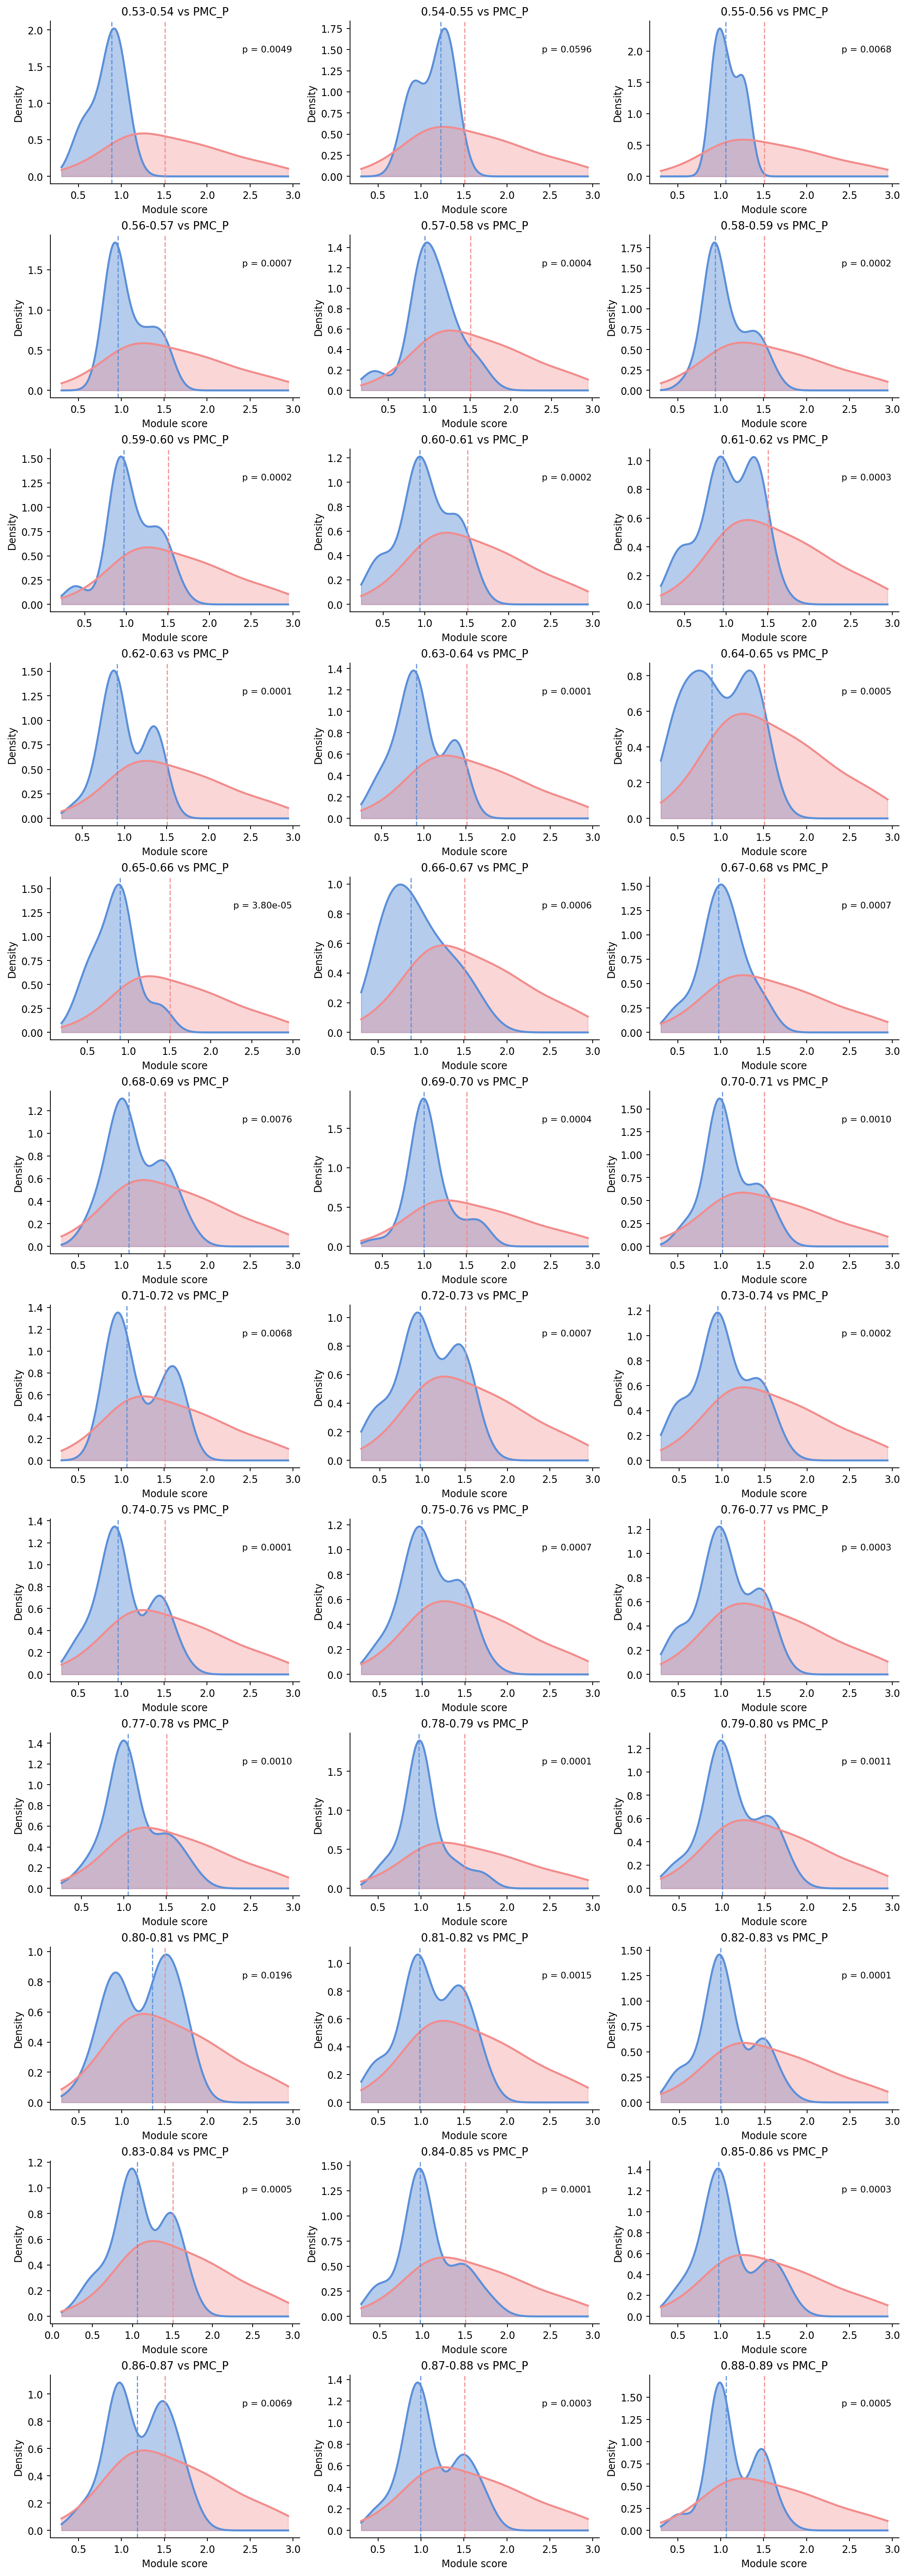

In [16]:
df_fine, fine_labels = make_fine_alpha_bins(
    df_virtual_alpha,
    low=0.53,
    high=0.89,
    step=0.01,        
    alpha_col="alpha_value",
    fine_col="alpha_fine_bin",
)


res_fine = compare_fine_bins_to_pmc(
    df_fine=df_fine,
    df_pmc=df_pmc,
    genes=genes,
    fine_col="alpha_fine_bin",
    score_col="module_score",
)

print(res_fine)


plot_fine_bin_density_vs_pmc(
    df_fine=df_fine,
    df_pmc=df_pmc,
    genes=genes,
    fine_labels=fine_labels,
    stat_df=res_fine,   # , mw_fdr
    fine_col="alpha_fine_bin",
    score_col="module_score",
    ncol=3,
)

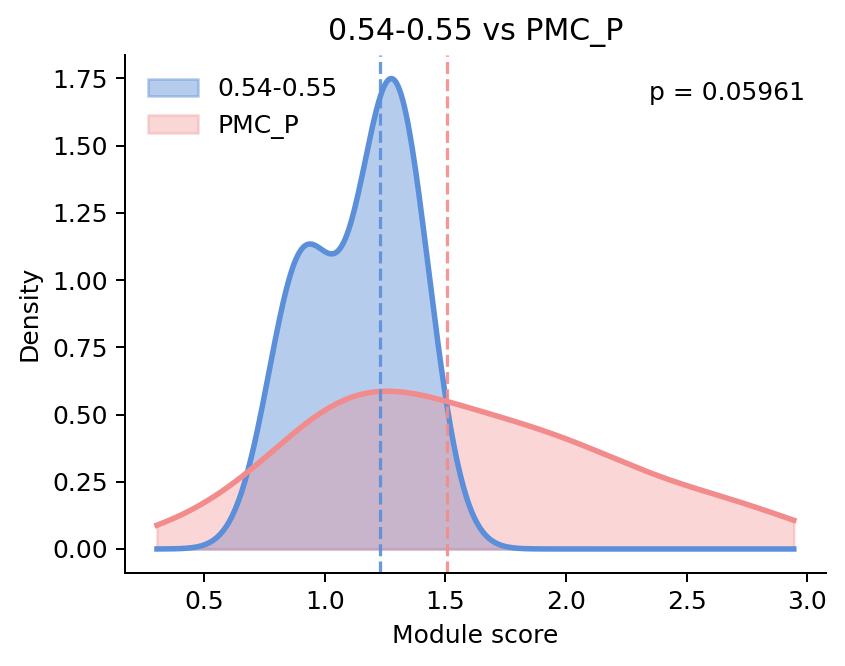

In [22]:
target_bin = "0.54-0.55"
score_col = "module_score"

df_fine_plot = make_module_score(df_fine, genes, score_col=score_col)
df_pmc_plot  = make_module_score(df_pmc, genes, score_col=score_col)

x = pd.to_numeric(
    df_fine_plot.loc[df_fine_plot["alpha_fine_bin"].astype(str) == target_bin, score_col],
    errors="coerce"
).dropna().values

pmc_scores = pd.to_numeric(df_pmc_plot[score_col], errors="coerce").dropna().values

u_stat, p_val = mannwhitneyu(x, pmc_scores, alternative="two-sided")

fig, ax = plt.subplots(figsize=(4.8, 3.8), dpi=180)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

color_bin = "#5B8FD9"
color_pmc = "#F28C8C"

all_vals = np.concatenate([x, pmc_scores])
xmin, xmax = all_vals.min() - 0.15, all_vals.max() + 0.15
x_grid = np.linspace(xmin, xmax, 400)

if len(x) >= 3 and np.std(x) > 1e-8:
    kde_x = gaussian_kde(x)
    yx = kde_x(x_grid)
    ax.fill_between(x_grid, 0, yx, color=color_bin, alpha=0.45, label=target_bin)
    ax.plot(x_grid, yx, color=color_bin, linewidth=2.2)

if len(pmc_scores) >= 3 and np.std(pmc_scores) > 1e-8:
    kde_p = gaussian_kde(pmc_scores)
    yp = kde_p(x_grid)
    ax.fill_between(x_grid, 0, yp, color=color_pmc, alpha=0.35, label="PMC_P")
    ax.plot(x_grid, yp, color=color_pmc, linewidth=2.2)

ax.axvline(np.median(x), color=color_bin, linestyle="--", linewidth=1.3, alpha=0.9)
ax.axvline(np.median(pmc_scores), color=color_pmc, linestyle="--", linewidth=1.3, alpha=0.9)

ax.set_title(f"{target_bin} vs PMC_P", fontsize=12)
ax.set_xlabel("Module score")
ax.set_ylabel("Density")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.97, 0.95,
    f"p = {p_val:.4g}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3449759/2053760168.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


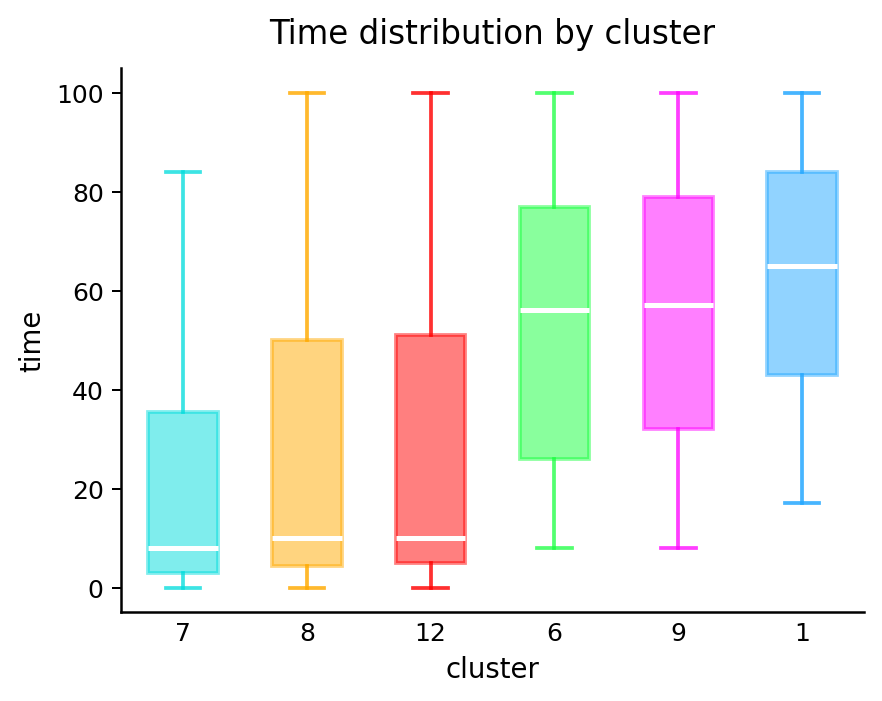

In [18]:
def plot_time_boxplot_by_cluster(
    adata,
    cluster_col="cluster",
    time_col="time",
    cluster_order=("7", "8", "12", "6", "9", "1"),
    showfliers=False,
    figsize=(5, 4),
    dpi=180,
):
    obs = adata.obs.copy()

    def get_1d_col(df, col):
        x = df[col]
        if isinstance(x, pd.DataFrame):
            print(f"[warn] {col!r} has duplicated columns,using first column")
            x = x.iloc[:, 0]
        return x

    clu = get_1d_col(obs, cluster_col).astype(str)
    tim = pd.to_numeric(get_1d_col(obs, time_col), errors="coerce")

    df = pd.DataFrame({
        "cluster": clu,
        "time": tim
    }).dropna()

    cluster_order = [str(x) for x in cluster_order]
    present_order = [c for c in cluster_order if c in df["cluster"].unique()]

    if len(present_order) == 0:
        raise ValueError(" cluster  adata.obs find.")

    data_list = [
        df.loc[df["cluster"] == c, "time"].values
        for c in present_order
    ]

    color_map = {
        "1":  "#25a8ffd7",
        "12": "#ff0000cf",
        "6":  "#15ff3cbb",
        "7":  "#00dcdcc2",
        "8":  "#ffaa00d2",
        "9":  "#ff00ffc1",
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data_list,
        labels=present_order,
        patch_artist=True,
        widths=0.56,
        showfliers=showfliers,
        medianprops=dict(color="white", linewidth=2.0),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        boxprops=dict(linewidth=1.5),
    )

    #  cluster:,,,
    for i, c in enumerate(present_order):
        col = color_map.get(c, "#bdbdbd")

        # box
        bp["boxes"][i].set_facecolor(col)
        bp["boxes"][i].set_edgecolor(col)
        bp["boxes"][i].set_alpha(0.5)

        # whiskers: 
        bp["whiskers"][2 * i].set_color(col)
        bp["whiskers"][2 * i + 1].set_color(col)

        # caps: 
        bp["caps"][2 * i].set_color(col)
        bp["caps"][2 * i + 1].set_color(col)

        # median
        bp["medians"][i].set_color("white")
        bp["medians"][i].set_linewidth(2.0)

    ax.set_xlabel("cluster", fontsize=11)
    ax.set_ylabel("time", fontsize=11)
    ax.set_title("Time distribution by cluster", fontsize=13, pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(axis="x", labelsize=10, length=0)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.0)

    plt.tight_layout()
    plt.show()

    return df

df_time_plot = plot_time_boxplot_by_cluster(
    adata,
    cluster_col="layer_name",
    time_col="t",
    cluster_order=("7", "8", "12", "6", "9", "1"),
    showfliers=False,
)

In [19]:
def plot_alpha_window_lineage_sankey_three_stage_keepall(
    adata,
    alpha_low=0.53,
    alpha_high=0.59,
    uid_col="uid",
    type_col="layer_name",         #  "cluster"
    frame_col="t",
    alpha_col="diff_alpha_post",
    type_order=("7", "8", "12", "6", "9", "1"),
    current_only=None,             #  ("7","8","12")
    choose="first_enter",          # "first_enter" / "last_in_bin"
    mid_types=("6", "9"),
    link_alpha=0.20,
    width=1120,
    height=720,
    verbose=True,
):
    obs0 = adata.obs.copy()

    def get_1d_col(df, col):
        x = df[col]
        if isinstance(x, pd.DataFrame):
            if verbose:
                print(f"[warn] column {col!r} ,using first column")
            x = x.iloc[:, 0]
        return x

    use_alpha_col = alpha_col
    if use_alpha_col not in obs0.columns:
        if alpha_col == "diff_alpha_post" and "diff_alpha" in obs0.columns:
            use_alpha_col = "diff_alpha"
        else:
            raise ValueError(f" alpha column: {alpha_col}")

    obs = pd.DataFrame({
        uid_col: get_1d_col(obs0, uid_col),
        type_col: get_1d_col(obs0, type_col),
        frame_col: get_1d_col(obs0, frame_col),
        use_alpha_col: get_1d_col(obs0, use_alpha_col),
    }).copy()

    def norm_id(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        if s in {"", "nan", "NaN", "None", "-1"}:
            return None
        try:
            xf = float(s)
            if np.isfinite(xf) and xf.is_integer():
                return str(int(xf))
        except Exception:
            pass
        return s

    def norm_type(x):
        if pd.isna(x):
            return None
        s = str(x).strip()
        try:
            xf = float(s)
            if np.isfinite(xf) and xf.is_integer():
                return str(int(xf))
        except Exception:
            pass
        return s

    def compress_types(types):
        out = []
        for t in types:
            t = str(t)
            if len(out) == 0 or t != out[-1]:
                out.append(t)
        return out

    def hex_to_rgba(hex_color, alpha=0.20):
        s = str(hex_color).strip().lstrip("#")
        if len(s) != 6:
            return f"rgba(180,180,180,{alpha})"
        r = int(s[0:2], 16)
        g = int(s[2:4], 16)
        b = int(s[4:6], 16)
        return f"rgba({r},{g},{b},{alpha})"

    obs[uid_col] = obs[uid_col].map(norm_id)
    obs[type_col] = obs[type_col].map(norm_type)
    obs[frame_col] = pd.to_numeric(obs[frame_col], errors="coerce")
    obs[use_alpha_col] = pd.to_numeric(obs[use_alpha_col], errors="coerce")

    obs = obs.dropna(subset=[uid_col, type_col, frame_col, use_alpha_col]).copy()
    obs = obs.sort_values([uid_col, frame_col]).reset_index(drop=True)

    if obs.empty:
        raise ValueError("after cleanup obs is empty.")

    type_order = [str(x) for x in type_order]
    if current_only is not None:
        current_only = set(map(str, current_only))

    mid_types = tuple(map(str, mid_types))
    mid_set = set(mid_types)

    rows = []
    skipped = []

    for uid, sub in obs.groupby(uid_col, sort=False):
        sub = sub.sort_values(frame_col).reset_index(drop=True).copy()
        if len(sub) == 0:
            skipped.append((uid, "empty"))
            continue

        in_bin = (sub[use_alpha_col] >= alpha_low) & (sub[use_alpha_col] < alpha_high)
        idxs = np.flatnonzero(in_bin.to_numpy())

        if len(idxs) == 0:
            skipped.append((uid, "not_in_bin"))
            continue

        if choose == "first_enter":
            k = int(idxs[0])
        elif choose == "last_in_bin":
            k = int(idxs[-1])
        else:
            raise ValueError("choose must be 'first_enter'  'last_in_bin'")

        current_type = str(sub.loc[k, type_col])

        if current_only is not None and current_type not in current_only:
            skipped.append((uid, "current_type_filtered"))
            continue

        #  alpha ,
        is_last_row = (k == len(sub) - 1)

        if is_last_row:
            # important:, current -> current -> Death
            hist = [current_type]
            mid_key = f"{current_type}__keep_mid"
            end_key = "Death"
        else:
            after_types = sub.loc[k + 1:, type_col].astype(str).tolist()
            hist = compress_types([current_type] + after_types)
            future_hist = hist[1:]   # current 

            if len(future_hist) == 0:
                # ,:current -> current -> current
                mid_key = f"{current_type}__keep_mid"
                end_key = f"{current_type}__keep_end"
            else:
                # missing 6/9 intermediate state
                mid_idx = next((i for i, t in enumerate(future_hist) if t in mid_set), None)

                if mid_idx is not None:
                    mid_key = future_hist[mid_idx]
                    end_key = future_hist[-1]
                else:
                    #  6/9,,the + 
                    #  8 -> 1  8 -> 1 -> 1
                    #  12 -> 3  12 -> 3 -> 3
                    first_change = future_hist[0]
                    mid_key = f"{first_change}__direct"
                    end_key = future_hist[-1]

        rows.append({
            "uid": uid,
            "current": current_type,
            "mid": mid_key,
            "end": end_key,
            "frame_in_bin": sub.loc[k, frame_col],
            "alpha_in_bin": sub.loc[k, use_alpha_col],
            "history_from_bin": " -> ".join(hist),
            "is_last_row": bool(is_last_row),
        })

    path_df = pd.DataFrame(rows)
    if path_df.empty:
        raise ValueError("missing.")

    # ----------  ----------
    edge12 = (
        path_df.groupby(["current", "mid"], as_index=False)
        .size()
        .rename(columns={"size": "value", "current": "source", "mid": "target"})
    )
    edge12["stage"] = "current_to_mid"

    edge23 = (
        path_df.groupby(["mid", "end"], as_index=False)
        .size()
        .rename(columns={"size": "value", "mid": "source", "end": "target"})
    )
    edge23["stage"] = "mid_to_end"

    edge_df = pd.concat([edge12, edge23], axis=0, ignore_index=True)

    # ----------  ----------
    color_map = {
        "1": "#25a8ff",
        "12": "#ff0000",
        "6": "#15ff3c",
        "7": "#00dcdc",
        "8": "#ffaa00",
        "9": "#ff00ff",
        "Death": "#BDBDBD",
    }

    def base_label(lbl):
        s = str(lbl)
        for suf in ["__keep_mid", "__keep_end", "__direct"]:
            s = s.replace(suf, "")
        return s

    def display_label(lbl):
        return base_label(lbl)

    def color_of(lbl):
        return color_map.get(base_label(lbl), "#BDBDBD")

    # ----------  ----------
    current_all = path_df["current"].astype(str).unique().tolist()
    mid_all = path_df["mid"].astype(str).unique().tolist()
    end_all = path_df["end"].astype(str).unique().tolist()

    stage1_nodes = [x for x in type_order if x in current_all] + [x for x in current_all if x not in set(type_order)]

    stage2_main = [x for x in mid_types if x in mid_all]
    stage2_direct = [x for x in mid_all if "__direct" in x]
    stage2_keep = [x for x in mid_all if "__keep_mid" in x]
    stage2_extra = [x for x in mid_all if x not in set(stage2_main + stage2_direct + stage2_keep)]
    stage2_nodes = stage2_main + stage2_direct + stage2_extra + stage2_keep

    end_pref = ["1", "6", "9", "Death"] + [x for x in type_order if x not in {"1", "6", "9"}]
    stage3_main = [x for x in end_pref if x in end_all]
    stage3_keep = [x for x in end_all if "__keep_end" in x]
    stage3_extra = [x for x in end_all if x not in set(stage3_main + stage3_keep)]
    stage3_nodes = stage3_main + stage3_extra + stage3_keep

    def fallback_positions(nodes, top=0.08, bottom=0.92):
        if len(nodes) == 0:
            return {}
        if len(nodes) == 1:
            return {nodes[0]: 0.50}
        ys = np.linspace(top, bottom, len(nodes))
        return {n: float(y) for n, y in zip(nodes, ys)}

    # , 1/6/9 
    stage1_y_map = {
        "7": 0.08,
        "8": 0.45,
        "12": 0.85,
    }
    stage2_y_map = {
        "6": 0.12,
        "9": 0.30,
        "1__direct": 0.44,
        "7__keep_mid": 0.56,
        "8__keep_mid": 0.74,
        "12__keep_mid": 0.90,
    }
    stage3_y_map = {
        "1": 0.08,
        "6": 0.26,
        "9": 0.46,
        "Death": 0.62,
        "7__keep_end": 0.72,
        "8__keep_end": 0.82,
        "12__keep_end": 0.92,
    }

    stage1_fb = fallback_positions(stage1_nodes)
    stage2_fb = fallback_positions(stage2_nodes)
    stage3_fb = fallback_positions(stage3_nodes)

    node_ids, node_labels, node_colors, node_x, node_y = [], [], [], [], []
    node_id_map = {}

    for n in stage1_nodes:
        nid = f"C::{n}"
        node_id_map[nid] = len(node_ids)
        node_ids.append(nid)
        node_labels.append(display_label(n))
        node_colors.append(color_of(n))
        node_x.append(0.02)
        node_y.append(stage1_y_map.get(n, stage1_fb[n]))

    for n in stage2_nodes:
        nid = f"M::{n}"
        node_id_map[nid] = len(node_ids)
        node_ids.append(nid)
        node_labels.append(display_label(n))
        node_colors.append(color_of(n))
        node_x.append(0.50)
        node_y.append(stage2_y_map.get(n, stage2_fb[n]))

    for n in stage3_nodes:
        nid = f"E::{n}"
        node_id_map[nid] = len(node_ids)
        node_ids.append(nid)
        node_labels.append(display_label(n))
        node_colors.append(color_of(n))
        node_x.append(0.98)
        node_y.append(stage3_y_map.get(n, stage3_fb[n]))

    # ----------  ----------
    sources, targets, values, link_labels, link_colors = [], [], [], [], []

    for _, r in edge12.iterrows():
        sidx = node_id_map[f"C::{r['source']}"]
        tidx = node_id_map[f"M::{r['target']}"]
        sources.append(sidx)
        targets.append(tidx)
        values.append(int(r["value"]))
        link_labels.append(f"{display_label(r['source'])} → {display_label(r['target'])}: {int(r['value'])}")
        link_colors.append(hex_to_rgba(color_of(r["source"]), alpha=link_alpha))

    for _, r in edge23.iterrows():
        sidx = node_id_map[f"M::{r['source']}"]
        tidx = node_id_map[f"E::{r['target']}"]
        sources.append(sidx)
        targets.append(tidx)
        values.append(int(r["value"]))
        link_labels.append(f"{display_label(r['source'])} → {display_label(r['target'])}: {int(r['value'])}")
        link_colors.append(hex_to_rgba(color_of(r["source"]), alpha=link_alpha))

    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=26,
                thickness=22,
                line=dict(color="rgba(60,60,60,0.35)", width=0.6),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y,
                hovertemplate="%{label}<extra></extra>",
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,
                label=link_labels,
                hovertemplate="%{label}<extra></extra>",
            ),
        )
    )

    fig.update_layout(
        title_text="",
        font=dict(size=22, color="#2c3e50"),
        width=width,
        height=height,
        margin=dict(l=20, r=20, t=10, b=10),
        paper_bgcolor="white",
        plot_bgcolor="white",
    )

    if verbose:
        skip_df = (
            pd.DataFrame(skipped, columns=["uid", "reason"])
            if len(skipped) > 0 else
            pd.DataFrame(columns=["uid", "reason"])
        )
        print(f"[ok] total paths: {len(path_df)}")
        print(f"[ok] deduplicated uid : {path_df['uid'].nunique()}")
        if not skip_df.empty:
            print("[skip]")
            print(skip_df["reason"].value_counts(dropna=False).sort_index())

    fig.show()
    return fig, edge_df, path_df

In [20]:
fig, edge_df, path_df = plot_alpha_window_lineage_sankey_three_stage_keepall(
    adata,
    alpha_low=0.54,
    alpha_high=0.55,
    uid_col="uid",
    type_col="layer_name",
    frame_col="t",
    alpha_col="diff_alpha_post",
    current_only=("7", "8", "12"),   
    choose="first_enter",
    mid_types=("6", "9"),
)

[ok] 总路径数: 5
[ok] 去重 uid 数: 5
[skip]
reason
current_type_filtered      18
not_in_bin               3137
Name: count, dtype: int64


In [21]:
res_fine.to_csv("p_value.csv")